## Extracting Chess Squares with Perspective Transformation ( image --> fen format)

<br>
<font size="4">
Notebook version of perspective_transformation.py file. You can  understand better all the process by observing cell by cell.<br>  You can use this file for testing 
</font>
<br><br><br><br>

<br>

#### Necessary Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import  math
import csv
from reportlab.graphics import renderPM
from PIL import Image
import os

 

<br>

#### Display Image

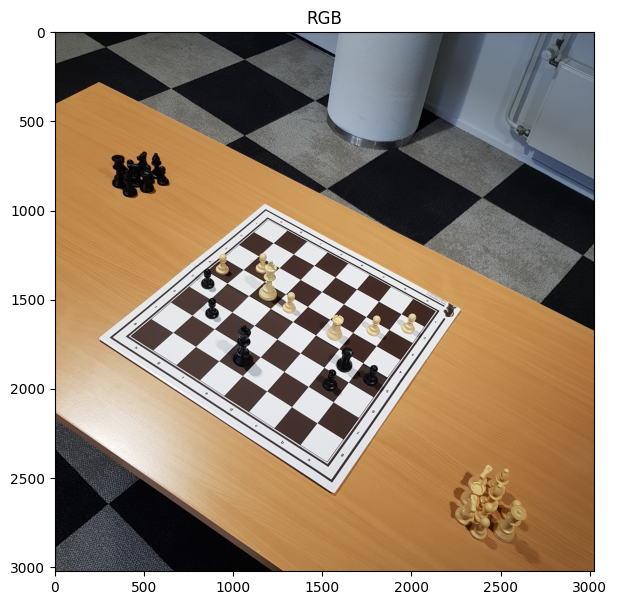

In [4]:
# Path of Image that you want to convert
image_path = r"images" # mudar path se for preciso
# read image and convert it to different color spaces 
image = cv2.imread(os.path.join((image_path),"G076_IMG089.jpg"))   #escolher a imagem
gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
rgb_image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9,7))
plt.imshow(rgb_image)
plt.title("RGB");

<br>


## Processing Image 
####  OTSU Threshold , Canny , dilate , HoughLinesP 

# falha G006_IMG086.jpg, G006_IMG119.jpg, G028_IMG015.jpg, G028_IMG062.jpg, G038_IMG088.jpg, G041_IMG048.jpg mas n fode.

fodeu G028_IMG098.jpg", G028_IMG101.jpg, G041_IMG088.jpg, fiquei nesta <

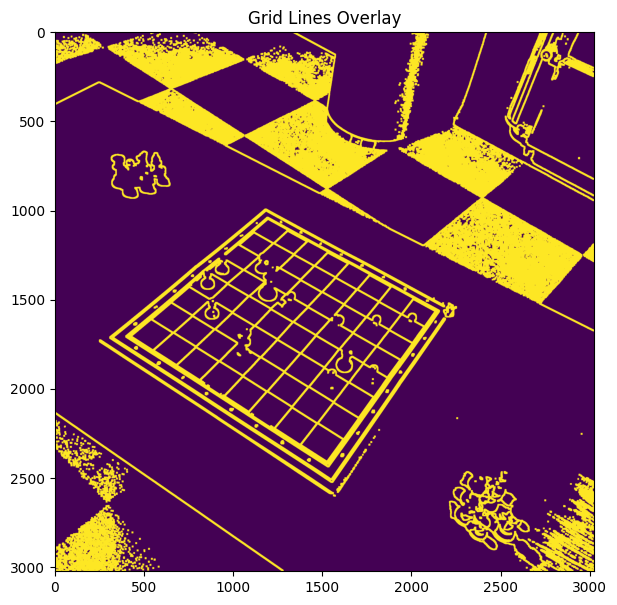

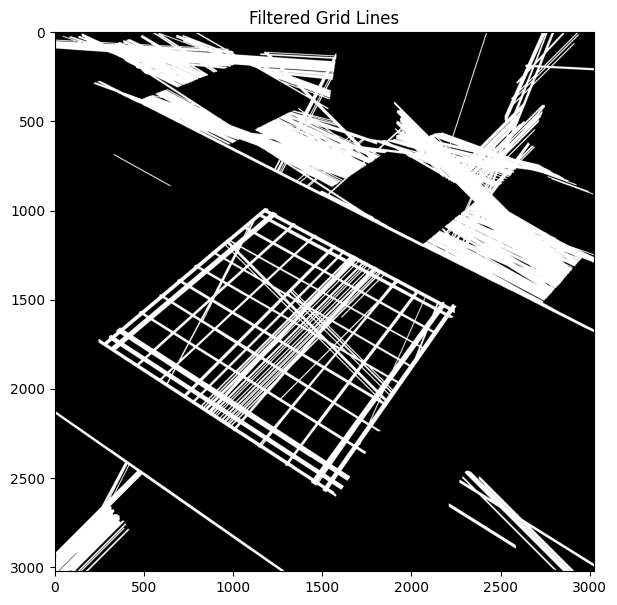

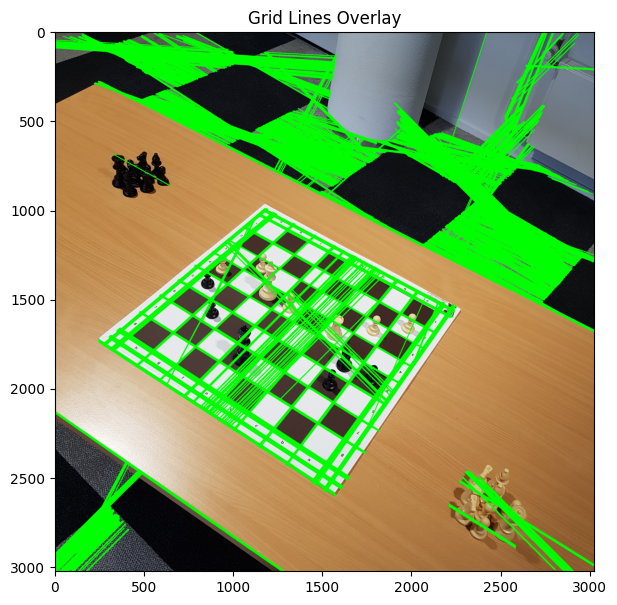

In [13]:
blurred = cv2.GaussianBlur(gray_image, (3, 3), 1.5)#added
ret, otsu_binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Apply morphological operations to clean up the image
kernel_open = np.ones((5, 5), np.uint8)
morph_image = cv2.morphologyEx(otsu_binary, cv2.MORPH_OPEN, kernel_open)
morph_image = cv2.morphologyEx(morph_image, cv2.MORPH_CLOSE, kernel_open)
# blurred = cv2.GaussianBlur(morph_image, (5, 5), 1.5) #

# Canny edge detection
canny_image = cv2.Canny(otsu_binary, 30, 255)               # ta na otsu binary caguei no morph

# Dilation to connect nearby edges
kernel = np.ones((9, 9), np.uint8)              # mudar isto might also cook ig
dilation_image = cv2.dilate(canny_image, kernel, iterations=1)

plt.figure(figsize=(9, 7))
plt.title("Grid Lines Overlay")
plt.imshow(dilation_image)
plt.show()

# Hough Lines with adjusted parameters
# Higher threshold to detect only stronger lines
# Higher minLineLength to favor longer lines (grid lines span the board)
# Lower maxLineGap to avoid connecting unrelated segments

#lines = cv2.HoughLinesP(dilation_image, 1, np.pi / 180, threshold=550, minLineLength=125, maxLineGap=120) #120
lines = cv2.HoughLinesP(dilation_image, 1, np.pi / 180, threshold=850, minLineLength=225, maxLineGap=110) #120

# Create an image that contains only black pixels
black_image = np.zeros_like(dilation_image)

# Group lines by similar angles to find dominant directions
if lines is not None:
    # Group lines by angle
    def group_lines_by_angle(lines, angle_threshold=5):
        angle_groups = {}
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Calculate line length (longer lines have more weight)
            length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            
            # Calculate angle (0-180 degrees)
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1)) % 180
            
            # Find if angle belongs to existing group
            found_group = False
            for group_angle in list(angle_groups.keys()):
                if abs(angle - group_angle) < angle_threshold:
                    angle_groups[group_angle].append((line, length))
                    found_group = True
                    break
                    
            if not found_group:
                angle_groups[angle] = [(line, length)]
        
        # Calculate total length of lines in each group
        group_lengths = {}
        for angle, lines_with_length in angle_groups.items():
            total_length = sum(length for _, length in lines_with_length)
            group_lengths[angle] = total_length
        
        # Sort groups by total line length (descending)
        sorted_groups = sorted(group_lengths.items(), key=lambda x: x[1], reverse=True)
        
        # Keep only the dominant groups (top 70% of total length)
        total_length = sum(group_lengths.values())
        threshold_length = 1 * total_length
        
        cumulative_length = 0
        dominant_angles = []
        for angle, length in sorted_groups:
            dominant_angles.append(angle)
            cumulative_length += length
            if cumulative_length >= threshold_length:
                break
        
        # Get all lines from dominant groups
        filtered_lines = []
        for angle in dominant_angles:
            for line, _ in angle_groups[angle]:
                filtered_lines.append(line)
        
        return filtered_lines
    
    # Apply filtering to keep only dominant line directions
    filtered_lines = group_lines_by_angle(lines)
    
    # Draw the filtered lines
    for line in filtered_lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(black_image, (x1, y1), (x2, y2), (255, 255, 255), 2)

# Apply a final dilation to connect any remaining gaps
kernel = np.ones((3, 3), np.uint8)
black_image = cv2.dilate(black_image, kernel, iterations=1)

# Display the result
plt.figure(figsize=(9, 7))
plt.title("Filtered Grid Lines")
plt.imshow(black_image, cmap="gray")
plt.show()

# Also show the grid lines overlaid on the original image
overlay_image = rgb_image.copy()

# Create a mask from the black_image
grid_mask = black_image > 0

# Apply grid lines to the overlay image
overlay_image[grid_mask] = [0, 255, 0]  # Green color for grid lines

# Display the overlay
plt.figure(figsize=(9, 7))
plt.title("Grid Lines Overlay")
plt.imshow(overlay_image)
plt.show()

<br>


#### Find Contours , sort contours points(4 point), and display valid squares on new fully black image

#### By saying "valid squares" , I mean geometrically. With some threshold value , 4 length of a square must be close to each other 

#### 4 point --> bottomright , topright , topleft , bottomleft

# In the code below, to tweak some parameters:
            is_square = (
                aspect_ratio < 2.2 and       # Sides should be similar (square-like) #mudei para 1
                diagonal_ratio < 2.2 and     # Diagonals should be similar
                (max_length - min_length) < 230  # Max difference between sides

Image dimensions: 3024x3024
Min square area: 6401.20, Max square area: 64012.03
Total contours found: 2892
Found 41 valid squares


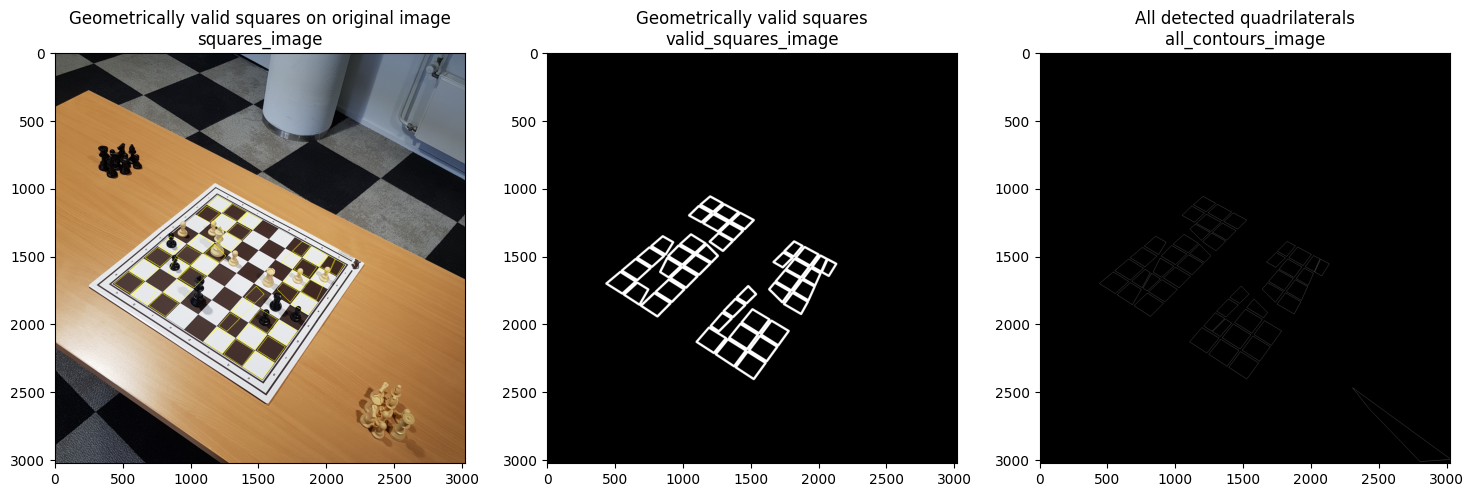

In [14]:
# Look for valid squares and check if squares are inside of board
import math  # Make sure to import math module

# Find contours
board_contours, hierarchy = cv2.findContours(black_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Blank image for displaying all contours
all_contours_image = np.zeros_like(black_image)

# Copy input image for displaying all squares 
squares_image = np.copy(image) 

# Blank image for displaying valid contours (squares)
valid_squares_image = np.zeros_like(black_image)

# Improved square filtering
valid_squares = []

# Calculate image size for reference
img_area = image.shape[0] * image.shape[1]

# Fine-tuned parameters specifically for chess squares
# Chess squares should be within a certain size range relative to the image
min_square_area = 0.0007 * img_area  # Adjust based on your chess board size
max_square_area = 0.007 * img_area   # Adjust based on your chess board size

# For the edge case with smaller squares, you might need to adjust:
# min_square_area = 0.0005 * img_area
# max_square_area = 0.01 * img_area

# Print parameters for debugging
print(f"Image dimensions: {image.shape[1]}x{image.shape[0]}")
print(f"Min square area: {min_square_area:.2f}, Max square area: {max_square_area:.2f}")
print(f"Total contours found: {len(board_contours)}")

# Loop through contours and filter them by deciding if they are potential squares
for contour in board_contours:
    area = cv2.contourArea(contour)
    if min_square_area < area < max_square_area:
        # Approximate the contour to a simpler shape
        epsilon = 0.03 * cv2.arcLength(contour, True)  # Balanced epsilon value #mudei de 0.03
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        # If polygon has 4 vertices (a quadrilateral)
        if len(approx) == 4:
            # 4 points of polygon
            pts = [pt[0].tolist() for pt in approx]

            # Create same pattern for points
            # Sort by x-coordinate (reverse for right-to-left order)
            index_sorted = sorted(pts, key=lambda x: x[0], reverse=True)

            # Adjust Y values to properly identify corners
            if index_sorted[0][1] < index_sorted[1][1]:
                cur = index_sorted[0]
                index_sorted[0] = index_sorted[1]
                index_sorted[1] = cur

            if index_sorted[2][1] > index_sorted[3][1]:
                cur = index_sorted[2]
                index_sorted[2] = index_sorted[3]
                index_sorted[3] = cur

            # bottomright(1), topright(2), topleft(3), bottomleft(4)
            pt1 = index_sorted[0]
            pt2 = index_sorted[1]
            pt3 = index_sorted[2]
            pt4 = index_sorted[3]

            # Calculate length of 4 sides of rectangle
            l1 = math.sqrt((pt1[0] - pt2[0])**2 + (pt1[1] - pt2[1])**2)
            l2 = math.sqrt((pt2[0] - pt3[0])**2 + (pt2[1] - pt3[1])**2)
            l3 = math.sqrt((pt3[0] - pt4[0])**2 + (pt3[1] - pt4[1])**2)
            l4 = math.sqrt((pt1[0] - pt4[0])**2 + (pt1[1] - pt4[1])**2)
 
            # Create a list of lengths
            lengths = [l1, l2, l3, l4]
            
            # Get the maximum and minimum lengths
            max_length = max(lengths)
            min_length = min(lengths)

            # Calculate the aspect ratio of the rectangle
            aspect_ratio = max_length / min_length if min_length > 0 else float('inf')
            
            # Calculate diagonals
            d1 = math.sqrt((pt1[0] - pt3[0])**2 + (pt1[1] - pt3[1])**2)
            d2 = math.sqrt((pt2[0] - pt4[0])**2 + (pt2[1] - pt4[1])**2)
            
            # Calculate diagonal ratio
            diagonal_ratio = max(d1, d2) / min(d1, d2) if min(d1, d2) > 0 else float('inf')
            
            # Chess squares should be square-ish, with reasonable ratios
            # Fine-tuned thresholds for chess squares
            is_square = (
                aspect_ratio < 2.2 and       # Sides should be similar (square-like) #mudei para 1
                diagonal_ratio < 2.2 and     # Diagonals should be similar
                (max_length - min_length) < 250  # Max difference between sides
            )
            
            if is_square:
                valid_square = True
                valid_squares.append(approx)
            else:
                valid_square = False
 
            # Draw all quadrilaterals to "all_contours_image"
            # Use integer coordinates to avoid drawing errors
            pt1_int = (int(pt1[0]), int(pt1[1]))
            pt2_int = (int(pt2[0]), int(pt2[1]))
            pt3_int = (int(pt3[0]), int(pt3[1]))
            pt4_int = (int(pt4[0]), int(pt4[1]))
            
            cv2.line(all_contours_image, pt1_int, pt2_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt2_int, pt3_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt3_int, pt4_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt1_int, pt4_int, (255, 255, 255), 1)
 
            if valid_square:
                # Draw the lines between the points for valid squares
                cv2.line(squares_image, pt1_int, pt2_int, (0, 255, 255), 2)  # Yellow
                cv2.line(squares_image, pt2_int, pt3_int, (0, 255, 255), 2)
                cv2.line(squares_image, pt3_int, pt4_int, (0, 255, 255), 2)
                cv2.line(squares_image, pt1_int, pt4_int, (0, 255, 255), 2)

                # Draw only valid squares to "valid_squares_image"
                cv2.line(valid_squares_image, pt1_int, pt2_int, (255, 255, 255), 15)
                cv2.line(valid_squares_image, pt2_int, pt3_int, (255, 255, 255), 15)
                cv2.line(valid_squares_image, pt3_int, pt4_int, (255, 255, 255), 15)
                cv2.line(valid_squares_image, pt1_int, pt4_int, (255, 255, 255), 15)

print(f"Found {len(valid_squares)} valid squares")

# Display results
plt.figure(figsize=(18, 15))

plt.subplot(131)
plt.title("Geometrically valid squares on original image\nsquares_image")
plt.imshow(cv2.cvtColor(squares_image, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title("Geometrically valid squares\nvalid_squares_image")
plt.imshow(valid_squares_image, cmap="gray")

plt.subplot(133)
plt.title("All detected quadrilaterals\nall_contours_image")
plt.imshow(all_contours_image, cmap="gray")
plt.show()

<br>


#### Dilation to the image that contains only valid squares (gemoetrically valid)

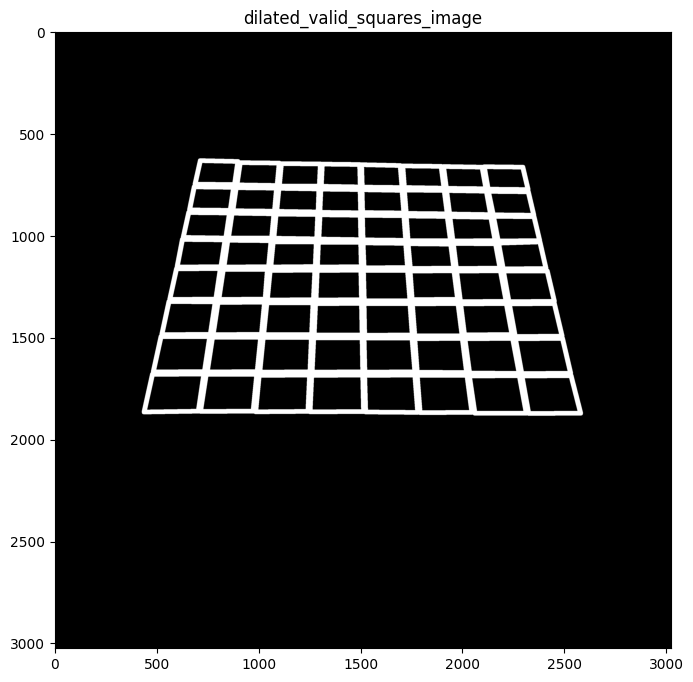

In [5]:
# Apply dilation to the valid_squares_image
kernel = np.ones((7, 7), np.uint8)
dilated_valid_squares_image = cv2.dilate(valid_squares_image, kernel, iterations=1)     #era 1 xD

plt.figure(figsize=(12,8))
plt.title("dilated_valid_squares_image")
plt.imshow(dilated_valid_squares_image,cmap="gray")

In [6]:
'''''# Find and apply mask to isolate the chessboard
# This assumes you've already created dilated_valid_squares_image

# Find all contours in the dilated image
contours, _ = cv2.findContours(dilated_valid_squares_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a blank mask for the chessboard
chessboard_mask = np.zeros_like(dilated_valid_squares_image)

if contours:
    # Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Fill the largest contour (the chessboard)
    cv2.drawContours(chessboard_mask, [largest_contour], 0, 255, -1)
    
    # Display the mask
    plt.figure(figsize=(12, 8))
    plt.title("Chessboard Mask")
    plt.imshow(chessboard_mask, cmap="gray")
    plt.show()
    
    # Apply the mask to get the final isolated chessboard
    isolated_chessboard = cv2.bitwise_and(dilated_valid_squares_image, dilated_valid_squares_image, mask=chessboard_mask)
    
    # Display the isolated chessboard
    plt.figure(figsize=(12, 8))
    plt.title("Isolated Chessboard")
    plt.imshow(isolated_chessboard, cmap="gray")
    plt.show()
    
    # Now set dilated_valid_squares_image to the isolated version
    dilated_valid_squares_image = isolated_chessboard
else:
    print("No contours found in the dilated image")'''

'\'\'# Find and apply mask to isolate the chessboard\n# This assumes you\'ve already created dilated_valid_squares_image\n\n# Find all contours in the dilated image\ncontours, _ = cv2.findContours(dilated_valid_squares_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)\n\n# Create a blank mask for the chessboard\nchessboard_mask = np.zeros_like(dilated_valid_squares_image)\n\nif contours:\n    # Find the largest contour by area\n    largest_contour = max(contours, key=cv2.contourArea)\n\n    # Fill the largest contour (the chessboard)\n    cv2.drawContours(chessboard_mask, [largest_contour], 0, 255, -1)\n\n    # Display the mask\n    plt.figure(figsize=(12, 8))\n    plt.title("Chessboard Mask")\n    plt.imshow(chessboard_mask, cmap="gray")\n    plt.show()\n\n    # Apply the mask to get the final isolated chessboard\n    isolated_chessboard = cv2.bitwise_and(dilated_valid_squares_image, dilated_valid_squares_image, mask=chessboard_mask)\n\n    # Display the isolated chessboard\n    plt.

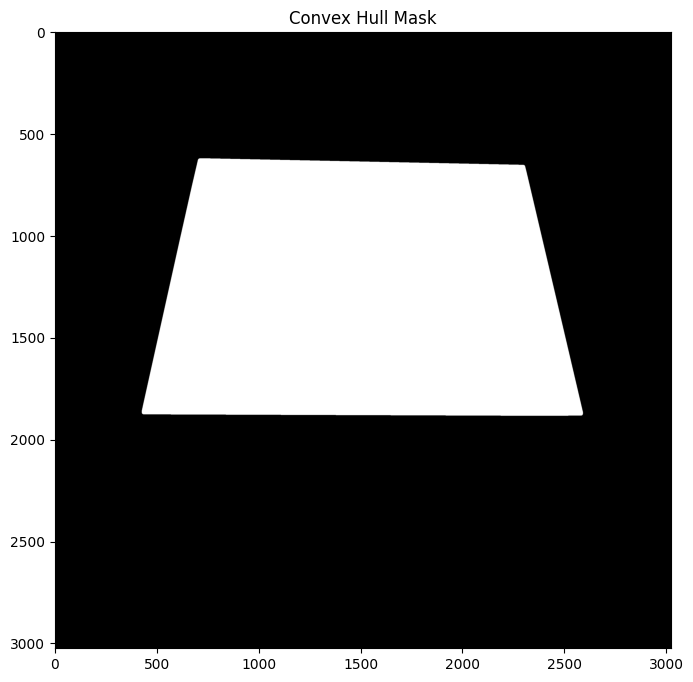

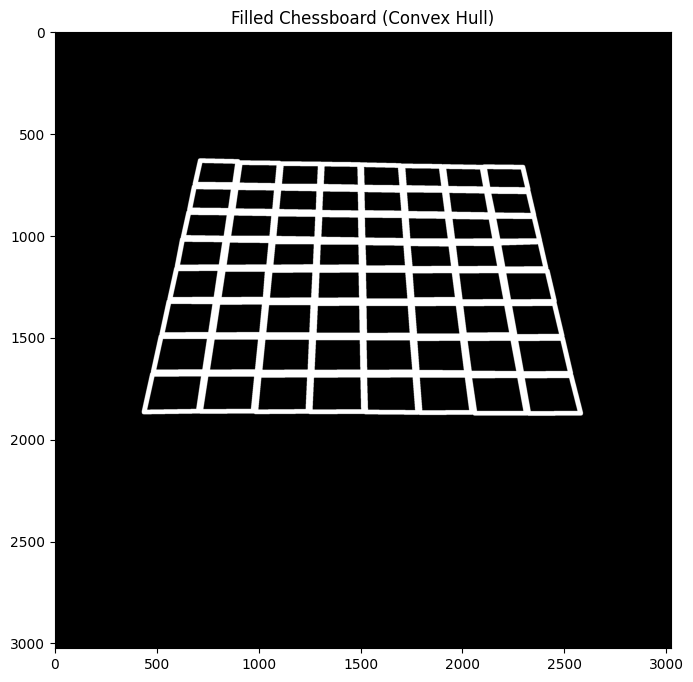

In [7]:
# Create a convex hull mask to fill the chessboard

# Find the contours of the original mask
contours, _ = cv2.findContours(dilated_valid_squares_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # Create a new mask with the convex hull of the largest contour
    hull_mask = np.zeros_like(dilated_valid_squares_image)
    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)
    cv2.drawContours(hull_mask, [hull], 0, 255, -1)
    
    # Display the convex hull mask
    plt.figure(figsize=(12, 8))
    plt.title("Convex Hull Mask")
    plt.imshow(hull_mask, cmap="gray")
    plt.show()
    
    # Apply the convex hull mask to get the final isolated chessboard
    filled_chessboard = cv2.bitwise_and(dilated_valid_squares_image, dilated_valid_squares_image, mask=hull_mask)
    
    # Display the result
    plt.figure(figsize=(12, 8))
    plt.title("Filled Chessboard (Convex Hull)")
    plt.imshow(filled_chessboard, cmap="gray")
    plt.show()
    
    # Update the chessboard mask and isolated image
    chessboard_mask = hull_mask
    dilated_valid_squares_image = filled_chessboard
else:
    print("No contours found in the chessboard mask")

# FROM HERE ON OUT IT IS THE CODE FROM THE FOUND REPOSITORY, CLAUDE, SO THIS IS WHERE MY WORK STOPS


In [8]:
'''# Orientation-agnostic corner detection that focuses on global corners
# This approach avoids assumptions about board orientation and handles thick lines

# Start with the chessboard mask
# First, simplify the mask by applying erosion followed by dilation (opening)
# This will remove small details and make the outline smoother
kernel = np.ones((5, 5), np.uint8)
smoothed_mask = cv2.morphologyEx(chessboard_mask, cv2.MORPH_OPEN, kernel)
smoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_CLOSE, kernel)

# Create a visualization image
visual_img = cv2.cvtColor(smoothed_mask.copy(), cv2.COLOR_GRAY2BGR)

# Find the contour of the chessboard (should be the largest contour)
contours, _ = cv2.findContours(smoothed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if not contours:
    print("No contours found!")
else:
    # Get the largest contour
    main_contour = max(contours, key=cv2.contourArea)
    
    # Draw the main contour
    cv2.drawContours(visual_img, [main_contour], 0, (0, 255, 255), 2)
    
    # Use the Douglas-Peucker algorithm to approximate the contour
    # This parameter controls how detailed the approximation is
    # Lower epsilon = more points, higher epsilon = fewer points
    # Try different values to get exactly 4 points
    
    # Start with a higher epsilon and gradually decrease if needed
    for epsilon_factor in [0.02, 0.015, 0.01, 0.005]:
        epsilon = epsilon_factor * cv2.arcLength(main_contour, True)
        approx = cv2.approxPolyDP(main_contour, epsilon, True)
        
        print(f"With epsilon factor {epsilon_factor}, found {len(approx)} points")
        
        # If we have 4 points, perfect! 
        if len(approx) == 4:
            break
        # If we have more than 4 points but not too many, we'll try to filter down to 4
        elif 4 < len(approx) <= 8:
            break
    
    # If we have more than 4 points, we need to find the 4 most significant ones
    if len(approx) > 4:
        # We'll score points based on their angle
        points = [tuple(point[0]) for point in approx]
        
        # Find centroid of all points
        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)
        
        # Calculate angles between adjacent points
        angles = []
        for i in range(len(points)):
            prev_idx = (i - 1) % len(points)
            next_idx = (i + 1) % len(points)
            
            # Calculate vectors
            v1 = (points[prev_idx][0] - points[i][0], points[prev_idx][1] - points[i][1])
            v2 = (points[next_idx][0] - points[i][0], points[next_idx][1] - points[i][1])
            
            # Calculate angle between vectors
            dot_product = v1[0]*v2[0] + v1[1]*v2[1]
            v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
            v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
            
            # Avoid division by zero
            if v1_mag * v2_mag == 0:
                cos_angle = 1.0  # Assume straight line (180 degrees) if magnitude is zero
            else:
                cos_angle = max(-1.0, min(1.0, dot_product / (v1_mag * v2_mag)))
            
            angle_rad = math.acos(cos_angle)
            angle_deg = math.degrees(angle_rad)
            
            # Sharper angles (closer to 0 or 360) have higher scores
            angle_score = 180 - abs(angle_deg - 180)
            
            # Also consider distance from centroid (farther is better for corners)
            dist_from_center = math.sqrt((points[i][0] - cx)**2 + (points[i][1] - cy)**2)
            
            # Combined score favors sharp angles far from center
            combined_score = angle_score + (0.01 * dist_from_center)
            
            angles.append((i, combined_score))
        
        # Sort by score (highest first)
        angles.sort(key=lambda x: x[1], reverse=True)
        
        # Take the indices of the top 4 corners
        best_indices = [idx for idx, _ in angles[:4]]
        best_indices.sort()  # Sort to maintain order around the contour
        
        # Extract the 4 best corners
        corners = [points[idx] for idx in best_indices]
    else:
        # We already have 4 or fewer points
        corners = [tuple(point[0]) for point in approx]
    
    # If we somehow ended up with fewer than 4 corners, fall back to convex hull approach
    if len(corners) < 4:
        print("Not enough corners found, falling back to convex hull method")
        # Find all white pixels
        white_pixels = np.where(smoothed_mask > 0)
        points = np.column_stack((white_pixels[1], white_pixels[0]))
        
        # Get the convex hull
        hull = cv2.convexHull(points.astype(np.float32))
        hull_points = [tuple(point[0]) for point in hull]
        
        # Use mathematical extremes to find corners
        corners = [
            min(hull_points, key=lambda p: p[0] + p[1]),  # Min x+y
            max(hull_points, key=lambda p: p[0] - p[1]),  # Max x-y
            min(hull_points, key=lambda p: p[0] - p[1]),  # Min x-y
            max(hull_points, key=lambda p: p[0] + p[1])   # Max x+y
        ]
    
    # Now we should have exactly 4 corners
    # But they might not be in the right order for drawing a quadrilateral
    # Let's sort them in clockwise order for proper drawing
    
    # First, find the centroid of the corners
    center_x = sum(p[0] for p in corners) / len(corners)
    center_y = sum(p[1] for p in corners) / len(corners)
    
    # Sort corners by their angle from the centroid
    def get_angle(point):
        return math.atan2(point[1] - center_y, point[0] - center_x)
    
    # Sort corners clockwise
    corners.sort(key=get_angle)
    
    # Draw all the points in the approximated contour
    for i, point in enumerate(corners):
        x, y = point
        cv2.circle(visual_img, (int(x), int(y)), 10, (0, 165, 255), -1)
        cv2.putText(visual_img, str(i), (int(x) + 10, int(y)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Draw the final quadrilateral
    corners_array = np.array(corners).reshape(-1, 1, 2).astype(np.int32)
    cv2.polylines(visual_img, [corners_array], True, (0, 255, 0), 3)
    
    # Display the results
    plt.figure(figsize=(12, 8))
    plt.title("Orientation-Agnostic Corner Detection")
    plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Print the corner coordinates without assuming orientation
    for i, corner in enumerate(corners):
        print(f"Corner {i}: ({int(corner[0])}, {int(corner[1])})")
    
    # If you need to map to specific corners (e.g., for perspective transform)
    # you can do this based on relative positions
    # This is one approach that works regardless of orientation
    corner_indices = {
        "top_left": corners.index(min(corners, key=lambda p: p[0] + p[1])),
        "top_right": corners.index(max(corners, key=lambda p: p[0] - p[1])),
        "bottom_left": corners.index(min(corners, key=lambda p: p[0] - p[1])),
        "bottom_right": corners.index(max(corners, key=lambda p: p[0] + p[1]))
    }
    
    # Now you can get corners by their logical position if needed
    top_left = corners[corner_indices["top_left"]]
    top_right = corners[corner_indices["top_right"]]
    bottom_left = corners[corner_indices["bottom_left"]]
    bottom_right = corners[corner_indices["bottom_right"]]
    
    # Print these for reference
    print("\nMapped to logical positions:")
    print(f"Top-left corner: ({int(top_left[0])}, {int(top_left[1])})")
    print(f"Top-right corner: ({int(top_right[0])}, {int(top_right[1])})")
    print(f"Bottom-left corner: ({int(bottom_left[0])}, {int(bottom_left[1])})")
    print(f"Bottom-right corner: ({int(bottom_right[0])}, {int(bottom_right[1])})")'''

'# Orientation-agnostic corner detection that focuses on global corners\n# This approach avoids assumptions about board orientation and handles thick lines\n\n# Start with the chessboard mask\n# First, simplify the mask by applying erosion followed by dilation (opening)\n# This will remove small details and make the outline smoother\nkernel = np.ones((5, 5), np.uint8)\nsmoothed_mask = cv2.morphologyEx(chessboard_mask, cv2.MORPH_OPEN, kernel)\nsmoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_CLOSE, kernel)\n\n# Create a visualization image\nvisual_img = cv2.cvtColor(smoothed_mask.copy(), cv2.COLOR_GRAY2BGR)\n\n# Find the contour of the chessboard (should be the largest contour)\ncontours, _ = cv2.findContours(smoothed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)\nif not contours:\n    print("No contours found!")\nelse:\n    # Get the largest contour\n    main_contour = max(contours, key=cv2.contourArea)\n\n    # Draw the main contour\n    cv2.drawContours(visual_img, [main

In [9]:
'''import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

kernel = np.ones((5, 5), np.uint8)
smoothed_mask = cv2.morphologyEx(chessboard_mask, cv2.MORPH_OPEN, kernel)
smoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_CLOSE, kernel)

# Create a visualization image
visual_img = cv2.cvtColor(smoothed_mask.copy(), cv2.COLOR_GRAY2BGR)

# Find the contour of the chessboard (should be the largest contour)
contours, _ = cv2.findContours(smoothed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found!")
else:
    # Get the largest contour
    main_contour = max(contours, key=cv2.contourArea)
    
    # Use the Douglas-Peucker algorithm to approximate the contour
    # This parameter controls how detailed the approximation is
    # Lower epsilon = more points, higher epsilon = fewer points
    # Try different values to get exactly 4 points
    
    # Start with a higher epsilon and gradually decrease if needed
    for epsilon_factor in [0.02, 0.015, 0.01, 0.005]:
        epsilon = epsilon_factor * cv2.arcLength(main_contour, True)
        approx = cv2.approxPolyDP(main_contour, epsilon, True)
        
        print(f"With epsilon factor {epsilon_factor}, found {len(approx)} points")
        
        # If we have 4 points, perfect! 
        if len(approx) == 4:
            break
        # If we have more than 4 points but not too many, we'll try to filter down to 4
        elif 4 < len(approx) <= 8:
            break
    
    # If we have more than 4 points, we need to find the 4 most significant ones
    if len(approx) > 4:
        # We'll score points based on their angle
        points = [tuple(point[0]) for point in approx]
        
        # Find centroid of all points
        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)
        
        # Calculate angles between adjacent points
        angles = []
        for i in range(len(points)):
            prev_idx = (i - 1) % len(points)
            next_idx = (i + 1) % len(points)
            
            # Calculate vectors
            v1 = (points[prev_idx][0] - points[i][0], points[prev_idx][1] - points[i][1])
            v2 = (points[next_idx][0] - points[i][0], points[next_idx][1] - points[i][1])
            
            # Calculate angle between vectors
            dot_product = v1[0]*v2[0] + v1[1]*v2[1]
            v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
            v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
            
            # Avoid division by zero
            if v1_mag * v2_mag == 0:
                cos_angle = 1.0  # Assume straight line (180 degrees) if magnitude is zero
            else:
                cos_angle = max(-1.0, min(1.0, dot_product / (v1_mag * v2_mag)))
            
            angle_rad = math.acos(cos_angle)
            angle_deg = math.degrees(angle_rad)
            
            # Sharper angles (closer to 0 or 360) have higher scores
            angle_score = 180 - abs(angle_deg - 180)
            
            # Also consider distance from centroid (farther is better for corners)
            dist_from_center = math.sqrt((points[i][0] - cx)**2 + (points[i][1] - cy)**2)
            
            # Combined score favors sharp angles far from center
            combined_score = angle_score + (0.01 * dist_from_center)
            
            angles.append((i, combined_score))
        
        # Sort by score (highest first)
        angles.sort(key=lambda x: x[1], reverse=True)
        
        # Take the indices of the top 4 corners
        best_indices = [idx for idx, _ in angles[:4]]
        best_indices.sort()  # Sort to maintain order around the contour
        
        # Extract the 4 best corners
        corners = [points[idx] for idx in best_indices]
    else:
        # We already have 4 or fewer points
        corners = [tuple(point[0]) for point in approx]
    
    # If we somehow ended up with fewer than 4 corners, fall back to convex hull approach
    if len(corners) < 4:
        print("Not enough corners found, falling back to convex hull method")
        # Find all white pixels
        white_pixels = np.where(smoothed_mask > 0)
        points = np.column_stack((white_pixels[1], white_pixels[0]))
        
        # Get the convex hull
        hull = cv2.convexHull(points.astype(np.float32))
        hull_points = [tuple(point[0]) for point in hull]
        
        # Use mathematical extremes to find corners
        corners = [
            min(hull_points, key=lambda p: p[0] + p[1]),  # Min x+y
            max(hull_points, key=lambda p: p[0] - p[1]),  # Max x-y
            min(hull_points, key=lambda p: p[0] - p[1]),  # Min x-y
            max(hull_points, key=lambda p: p[0] + p[1])   # Max x+y
        ]
    
    # Now we should have exactly 4 corners
    # But they might not be in the right order for drawing a quadrilateral
    # Let's sort them in clockwise order for proper drawing
    
    # First, find the centroid of the corners
    center_x = sum(p[0] for p in corners) / len(corners)
    center_y = sum(p[1] for p in corners) / len(corners)
    
    # Sort corners by their angle from the centroid
    def get_angle(point):
        return math.atan2(point[1] - center_y, point[0] - center_x)
    
    # Sort corners clockwise
    corners.sort(key=get_angle)
    
    # Create a visualization image
    visual_img = cv2.cvtColor(smoothed_mask.copy(), cv2.COLOR_GRAY2BGR)
    
    # Draw main contour
    cv2.drawContours(visual_img, [main_contour], 0, (0, 255, 255), 2)
    
    # Draw the center point
    cv2.circle(visual_img, (int(center_x), int(center_y)), 10, (255, 165, 0), -1)
    
    # Simplified approach - just use corners in the order they're found
    colors = [(0, 0, 255), (0, 255, 0), (255, 255, 0), (255, 0, 0)]  # Red, Green, Yellow, Blue
    for i, corner in enumerate(corners):
        x, y = int(corner[0]), int(corner[1])
        color = colors[i % len(colors)]
        
        # Draw the corner
        cv2.circle(visual_img, (x, y), 15, color, -1)
        
        # Add the corner number label
        cv2.putText(visual_img, f"C{i}", (x - 20, y - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)
    
    # Draw the quadrilateral connecting the corners in their original order
    corners_array = np.array([(int(c[0]), int(c[1])) for c in corners]).reshape(-1, 1, 2)
    cv2.polylines(visual_img, [corners_array], True, (0, 255, 0), 3)
    
    # Display the results
    plt.figure(figsize=(12, 8))
    plt.title("Corner Detection (Ordered by Detection)")
    plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Print the corner coordinates in their original order
    for i, corner in enumerate(corners):
        print(f"Corner {i}: ({int(corner[0])}, {int(corner[1])})")'''

'import cv2\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport math\n\nkernel = np.ones((5, 5), np.uint8)\nsmoothed_mask = cv2.morphologyEx(chessboard_mask, cv2.MORPH_OPEN, kernel)\nsmoothed_mask = cv2.morphologyEx(smoothed_mask, cv2.MORPH_CLOSE, kernel)\n\n# Create a visualization image\nvisual_img = cv2.cvtColor(smoothed_mask.copy(), cv2.COLOR_GRAY2BGR)\n\n# Find the contour of the chessboard (should be the largest contour)\ncontours, _ = cv2.findContours(smoothed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)\n\nif not contours:\n    print("No contours found!")\nelse:\n    # Get the largest contour\n    main_contour = max(contours, key=cv2.contourArea)\n\n    # Use the Douglas-Peucker algorithm to approximate the contour\n    # This parameter controls how detailed the approximation is\n    # Lower epsilon = more points, higher epsilon = fewer points\n    # Try different values to get exactly 4 points\n\n    # Start with a higher epsilon and gradually decrease if needed\

With epsilon factor 0.02, found 4 points


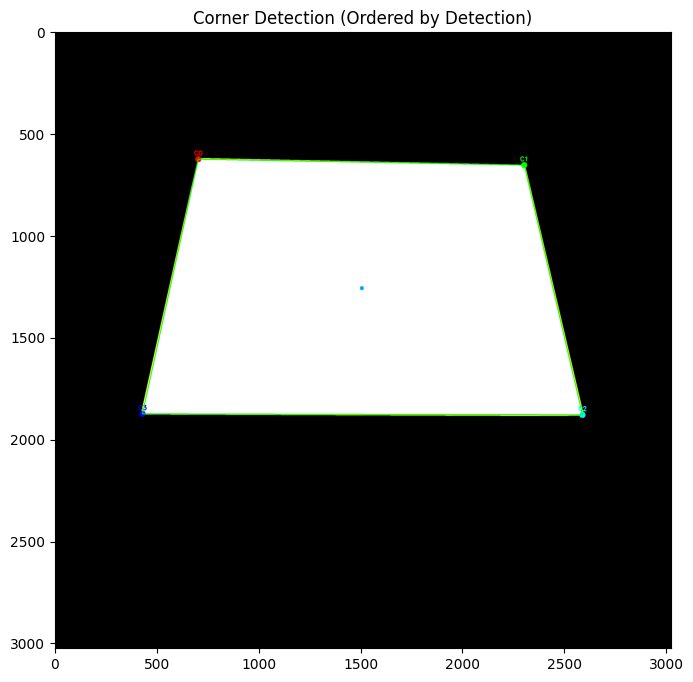

Corner 0: (703, 624)
Corner 1: (2303, 653)
Corner 2: (2589, 1879)
Corner 3: (429, 1874)


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# Create a visualization image
visual_img = cv2.cvtColor(chessboard_mask.copy(), cv2.COLOR_GRAY2BGR)

# Find the contour of the chessboard (should be the largest contour)
contours, _ = cv2.findContours(chessboard_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found!")
else:
    # Get the largest contour
    main_contour = max(contours, key=cv2.contourArea)
    
    # Use the Douglas-Peucker algorithm to approximate the contour
    # This parameter controls how detailed the approximation is
    # Try different values to get exactly 4 points
    
    # Start with a higher epsilon and gradually decrease if needed
    for epsilon_factor in [0.02, 0.015, 0.01, 0.005]:
        epsilon = epsilon_factor * cv2.arcLength(main_contour, True)
        approx = cv2.approxPolyDP(main_contour, epsilon, True)
        
        print(f"With epsilon factor {epsilon_factor}, found {len(approx)} points")
        
        # If we have 4 points, perfect! 
        if len(approx) == 4:
            break
        # If we have more than 4 points but not too many, we'll try to filter down to 4
        elif 4 < len(approx) <= 8:
            break
    
    # If we have more than 4 points, we need to find the 4 most significant ones
    if len(approx) > 4:
        # We'll score points based on their angle
        points = [tuple(point[0]) for point in approx]
        
        # Find centroid of all points
        cx = sum(p[0] for p in points) / len(points)
        cy = sum(p[1] for p in points) / len(points)
        
        # Calculate angles between adjacent points
        angles = []
        for i in range(len(points)):
            prev_idx = (i - 1) % len(points)
            next_idx = (i + 1) % len(points)
            
            # Calculate vectors
            v1 = (points[prev_idx][0] - points[i][0], points[prev_idx][1] - points[i][1])
            v2 = (points[next_idx][0] - points[i][0], points[next_idx][1] - points[i][1])
            
            # Calculate angle between vectors
            dot_product = v1[0]*v2[0] + v1[1]*v2[1]
            v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
            v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
            
            # Avoid division by zero
            if v1_mag * v2_mag == 0:
                cos_angle = 1.0  # Assume straight line (180 degrees) if magnitude is zero
            else:
                cos_angle = max(-1.0, min(1.0, dot_product / (v1_mag * v2_mag)))
            
            angle_rad = math.acos(cos_angle)
            angle_deg = math.degrees(angle_rad)
            
            # Sharper angles (closer to 0 or 360) have higher scores
            angle_score = 180 - abs(angle_deg - 180)
            
            # Also consider distance from centroid (farther is better for corners)
            dist_from_center = math.sqrt((points[i][0] - cx)**2 + (points[i][1] - cy)**2)
            
            # Combined score favors sharp angles far from center
            combined_score = angle_score + (0.01 * dist_from_center)
            
            angles.append((i, combined_score))
        
        # Sort by score (highest first)
        angles.sort(key=lambda x: x[1], reverse=True)
        
        # Take the indices of the top 4 corners
        best_indices = [idx for idx, _ in angles[:4]]
        best_indices.sort()  # Sort to maintain order around the contour
        
        # Extract the 4 best corners
        corners = [points[idx] for idx in best_indices]
    else:
        # We already have 4 or fewer points
        corners = [tuple(point[0]) for point in approx]
    
    # If we somehow ended up with fewer than 4 corners, fall back to convex hull approach
    if len(corners) < 4:
        print("Not enough corners found, falling back to convex hull method")
        # Find all white pixels
        white_pixels = np.where(chessboard_mask > 0)
        points = np.column_stack((white_pixels[1], white_pixels[0]))
        
        # Get the convex hull
        hull = cv2.convexHull(points.astype(np.float32))
        hull_points = [tuple(point[0]) for point in hull]
        
        # Use mathematical extremes to find corners
        corners = [
            min(hull_points, key=lambda p: p[0] + p[1]),  # Min x+y
            max(hull_points, key=lambda p: p[0] - p[1]),  # Max x-y
            min(hull_points, key=lambda p: p[0] - p[1]),  # Min x-y
            max(hull_points, key=lambda p: p[0] + p[1])   # Max x+y
        ]
    
    # Now we should have exactly 4 corners
    # Let's sort them in clockwise order for proper drawing
    
    # First, find the centroid of the corners
    center_x = sum(p[0] for p in corners) / len(corners)
    center_y = sum(p[1] for p in corners) / len(corners)
    
    # Sort corners by their angle from the centroid
    def get_angle(point):
        return math.atan2(point[1] - center_y, point[0] - center_x)
    
    # Sort corners clockwise
    corners.sort(key=get_angle)
    
    # Draw main contour
    cv2.drawContours(visual_img, [main_contour], 0, (0, 255, 255), 2)
    
    # Draw the center point
    cv2.circle(visual_img, (int(center_x), int(center_y)), 10, (255, 165, 0), -1)
    
    # Draw corners in the order they're found
    colors = [(0, 0, 255), (0, 255, 0), (255, 255, 0), (255, 0, 0)]  # Red, Green, Yellow, Blue
    for i, corner in enumerate(corners):
        x, y = int(corner[0]), int(corner[1])
        color = colors[i % len(colors)]
        
        # Draw the corner
        cv2.circle(visual_img, (x, y), 15, color, -1)
        
        # Add the corner number label
        cv2.putText(visual_img, f"C{i}", (x - 20, y - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)
    
    # Draw the quadrilateral connecting the corners in their original order
    corners_array = np.array([(int(c[0]), int(c[1])) for c in corners]).reshape(-1, 1, 2)
    cv2.polylines(visual_img, [corners_array], True, (0, 255, 0), 3)
    
    # Display the results
    plt.figure(figsize=(12, 8))
    plt.title("Corner Detection (Ordered by Detection)")
    plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Print the corner coordinates in their original order
    for i, corner in enumerate(corners):
        print(f"Corner {i}: ({int(corner[0])}, {int(corner[1])})")

# falhou G006_IMG048.jpg,G019_IMG082.jpg, G033_IMG088.jpg

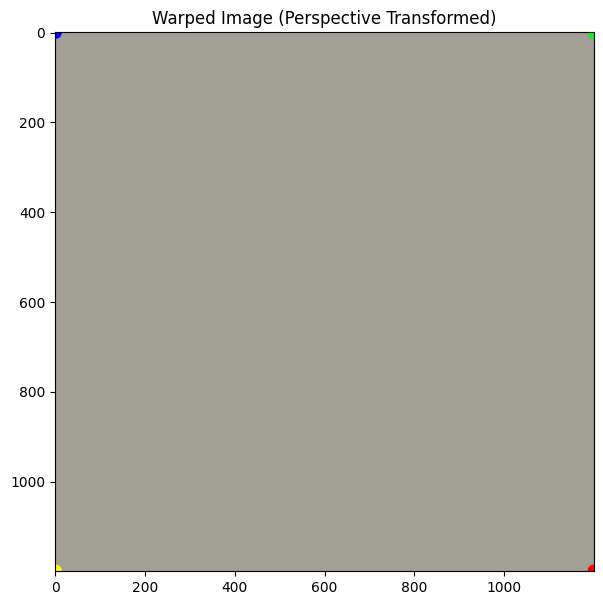

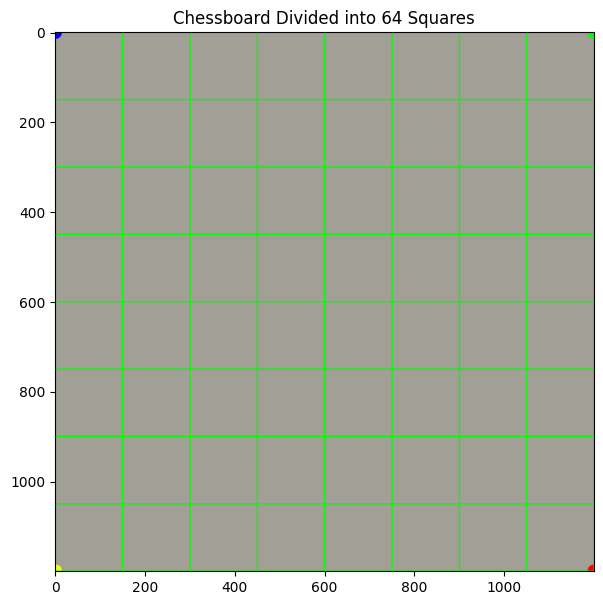

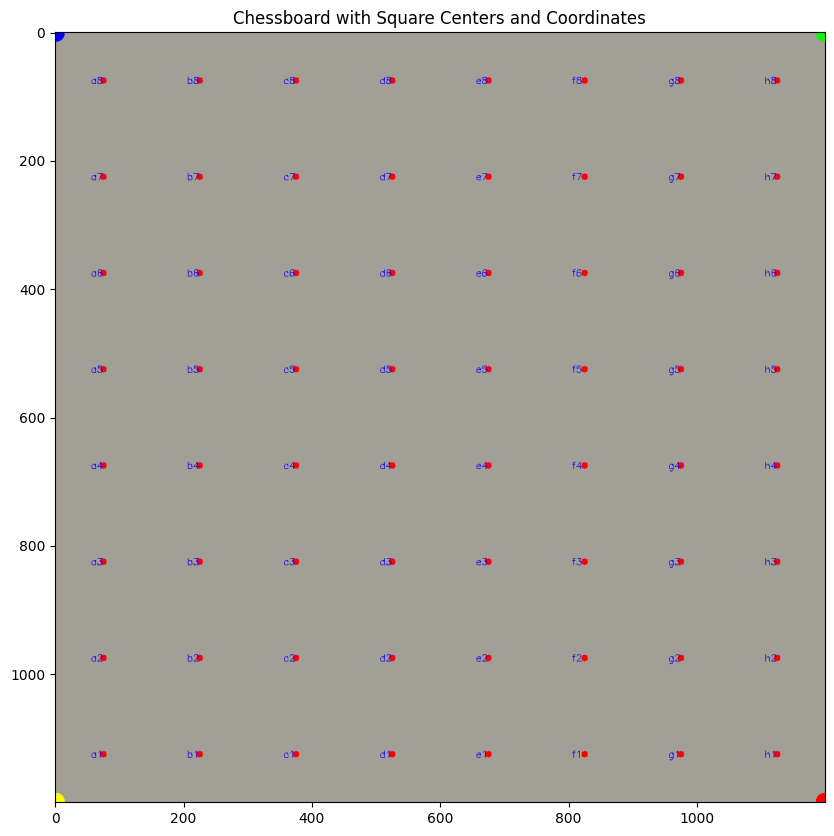

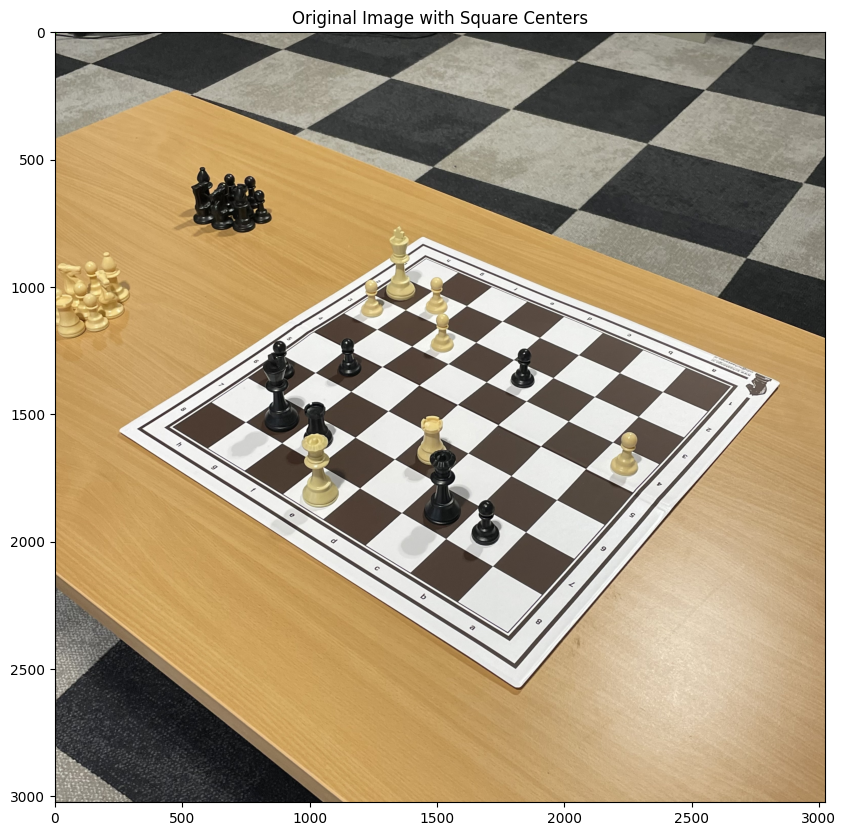

First few squares with their coordinates:
Square a1: Center at (0, 0)
Square b1: Center at (0, 0)
Square c1: Center at (0, 0)
Square d1: Center at (0, 0)
Square e1: Center at (0, 0)


In [67]:
# Apply Perspective Transformation

# Read the original image
# If you're running this as a continuation of the corner detection, 
# make sure to reload the original image
# image = cv2.imread(image_path)
# rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define the four source points (use the corners we detected)
# Make sure these are ordered correctly: [top_left, top_right, bottom_left, bottom_right]
extreme_points_list = np.float32([
    [top_left[0], top_left[1]],
    [top_right[0], top_right[1]],
    [bottom_left[0], bottom_left[1]],
    [bottom_right[0], bottom_right[1]]
])

# Set the output image dimensions
threshold = 0  # Extra space on all sides
width, height = 1200, 1200

# Define the destination points (shifted by 'threshold' on all sides)
dst_pts = np.float32([
    [threshold, threshold],  # Top-left
    [width + threshold, threshold],  # Top-right
    [threshold, height + threshold],  # Bottom-left
    [width + threshold, height + threshold]  # Bottom-right
])

# Compute the perspective transform matrix
M = cv2.getPerspectiveTransform(extreme_points_list, dst_pts)

# Apply the transformation with extra width and height
warped_image = cv2.warpPerspective(rgb_image, M, (width + 2 * threshold, height + 2 * threshold))

# Mark the corners in the warped image for verification
cv2.circle(warped_image, (threshold, threshold), 15, (0, 0, 255), -1)  # Top-left
cv2.circle(warped_image, (width + threshold, threshold), 15, (0, 255, 0), -1)  # Top-right
cv2.circle(warped_image, (threshold, height + threshold), 15, (255, 255, 0), -1)  # Bottom-left
cv2.circle(warped_image, (width + threshold, height + threshold), 15, (255, 0, 0), -1)  # Bottom-right

# Display the result
plt.figure(figsize=(9, 7))
plt.imshow(warped_image)
plt.title("Warped Image (Perspective Transformed)")
plt.show()

# Next, divide the board into 64 squares
rows, cols = 8, 8
square_width = width // cols
square_height = height // rows

# Create a copy to draw the grid lines
grid_image = warped_image.copy()

# Draw grid lines to divide the board into 64 squares
for i in range(rows + 1):
    y = i * square_height
    cv2.line(grid_image, (0, y), (width, y), (0, 255, 0), 2)

for j in range(cols + 1):
    x = j * square_width
    cv2.line(grid_image, (x, 0), (x, height), (0, 255, 0), 2)

# Display the result with grid
plt.figure(figsize=(9, 7))
plt.imshow(grid_image)
plt.title("Chessboard Divided into 64 Squares")
plt.show()

# Create a list to store all 64 squares with their coordinates
squares_data = []

# Extract each square's coordinates in the warped image
# Go from bottom to top (rank 1 to 8) and left to right (file a to h)
for i in range(rows - 1, -1, -1):  # Start from bottom row (rank 1)
    for j in range(cols):  # Left to right (file a to h)
        # Define the 4 corners of each square
        top_left_square = (j * square_width, i * square_height)
        top_right_square = ((j + 1) * square_width, i * square_height)
        bottom_left_square = (j * square_width, (i + 1) * square_height)
        bottom_right_square = ((j + 1) * square_width, (i + 1) * square_height)
        
        # Calculate center of the square
        center_x = (top_left_square[0] + bottom_right_square[0]) // 2
        center_y = (top_left_square[1] + bottom_right_square[1]) // 2
        
        # Append to the list
        squares_data.append({
            "center": (center_x, center_y),
            "corners": [bottom_right_square, top_right_square, top_left_square, bottom_left_square],
            "rank": 8 - i,  # Chess rank (1-8)
            "file": chr(97 + j)  # Chess file (a-h)
        })

# For visualization, create a copy of the warped image
square_centers_image = warped_image.copy()

# Draw square centers and labels
for square in squares_data:
    center = square["center"]
    rank = square["rank"]
    file = square["file"]
    
    # Draw center point
    cv2.circle(square_centers_image, center, 5, (255, 0, 0), -1)
    
    # Add coordinate label
    label = f"{file}{rank}"
    cv2.putText(square_centers_image, label, (center[0] - 20, center[1] + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# Display the result with square centers and labels
plt.figure(figsize=(12, 10))
plt.imshow(square_centers_image)
plt.title("Chessboard with Square Centers and Coordinates")
plt.show()

# Now we need to map these warped coordinates back to the original image
# Convert square centers to numpy array for transformation
square_centers_warped = np.array([square["center"] for square in squares_data], dtype=np.float32).reshape(-1, 1, 2)

# Compute the inverse perspective transformation matrix
M_inv = cv2.invert(M)[1]

# Transform centers back to original image coordinates
square_centers_original = cv2.perspectiveTransform(square_centers_warped, M_inv)

# Update the squares_data with original image coordinates
for i, square in enumerate(squares_data):
    square["original_center"] = (
        int(square_centers_original[i][0][0]),
        int(square_centers_original[i][0][1])
    )

# Visualize the square centers on the original image
original_with_centers = rgb_image.copy()

for square in squares_data:
    center = square["original_center"]
    rank = square["rank"]
    file = square["file"]
    
    # Draw center point
    cv2.circle(original_with_centers, center, 8, (0, 255, 0), -1)
    
    # Add coordinate label
    label = f"{file}{rank}"
    cv2.putText(original_with_centers, label, (center[0] - 15, center[1] + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Display the result
plt.figure(figsize=(12, 10))
plt.imshow(original_with_centers)
plt.title("Original Image with Square Centers")
plt.show()

# Print the first few square coordinates for verification
print("First few squares with their coordinates:")
for i in range(5):
    sq = squares_data[i]
    print(f"Square {sq['file']}{sq['rank']}: Center at {sq['original_center']}")

#rafini


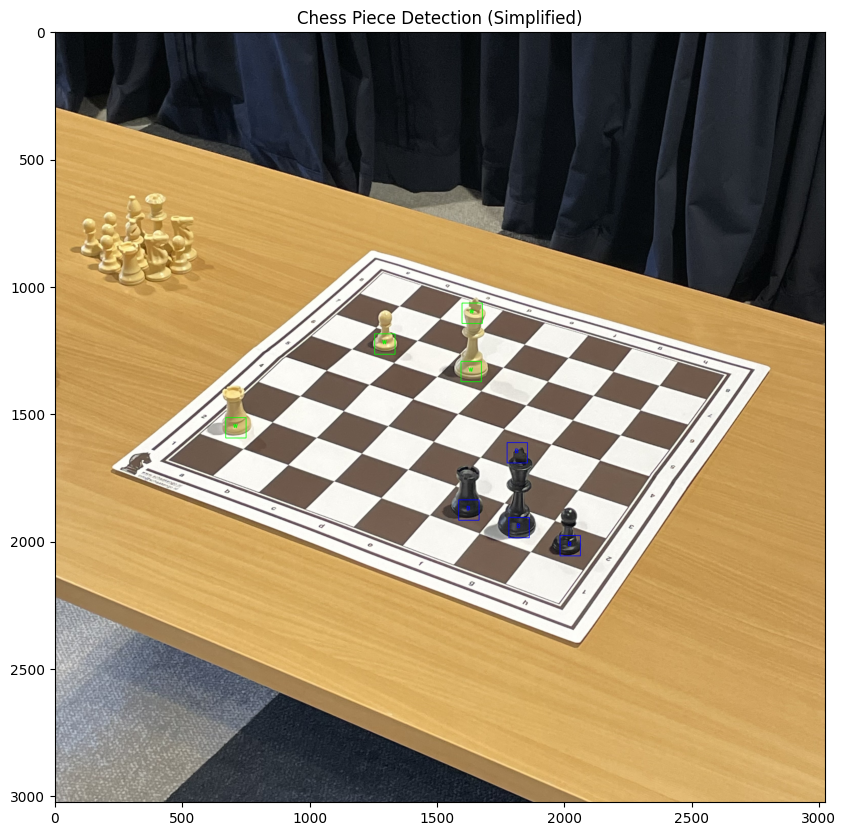

Total pieces detected: 8
White pieces: 4
Black pieces: 4

Board Matrix (1 for piece, 0 for empty):
[0, 0, 1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0]
[1, 0, 0, 0, 0, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0]

Output for assignment submission:
Piece counts: {'white': 4, 'black': 4, 'total': 8}

White piece positions:
['a2', 'b6', 'd6', 'c8']

Black piece positions:
['f2', 'g2', 'h2', 'f4']


In [172]:
# Simplified Chess Piece Detection Algorithm
# Focused ONLY on detecting piece presence and color, not piece type

def detect_pieces_simple(rgb_image, squares_data):
    """
    Simplified detection that only identifies if a piece is present and its color
    
    Args:
        rgb_image: Original RGB image
        squares_data: List of dictionaries containing square information
        
    Returns:
        Dictionary with piece information and visualization
    """
    # Create a visualization copy of the original image
    visualization = rgb_image.copy()
    
    # Convert to grayscale for simpler processing
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    
    # Initialize counters and storage
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # Process each square individually
    for square in squares_data:
        # Get the original center of the square
        center = square["original_center"]
        
        # Get square coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')  # 0-7
        rank_idx = 8 - rank  # 0-7 (8 is at the top in chess notation)
        
        # Determine if square is dark or light on the chessboard
        is_dark_square = (file_idx + rank_idx) % 2 == 1
        
        # Define a region around the center to analyze
        roi_size = 40  # Larger ROI to capture more of the piece
        roi_x = max(0, center[0] - roi_size)
        roi_y = max(0, center[1] - roi_size)
        roi_width = min(roi_size*2, rgb_image.shape[1] - roi_x)
        roi_height = min(roi_size*2, rgb_image.shape[0] - roi_y)
        
        # Extract the region of interest
        roi_gray = gray_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        roi_color = rgb_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        
        if roi_gray.size == 0:
            continue  # Skip if ROI is outside the image
        
        # FEATURE 1: Standard deviation of brightness (pieces create shadows and highlights)
        std_dev = np.std(roi_gray)
        
        # FEATURE 2: Edge density (pieces have more edges)
        edges = cv2.Canny(roi_gray, 50, 150)
        edge_pixels = np.count_nonzero(edges)
        edge_density = edge_pixels / roi_gray.size
        
        # FEATURE 3: Mean color values (for color determination)
        mean_gray = np.mean(roi_gray)
        mean_r = np.mean(roi_color[:,:,0])
        mean_g = np.mean(roi_color[:,:,1])
        mean_b = np.mean(roi_color[:,:,2])
        
        # Calculate a simple "piece presence score"
        piece_score = std_dev + (edge_density * 500)
        
        # Threshold for piece detection - adjust as needed
        # Higher on dark squares since they naturally have more contrast
        piece_threshold = 25 if is_dark_square else 20
        
        # Determine if there's a piece
        has_piece = piece_score > piece_threshold
        
        # Determine piece color if a piece is present
        piece_color = "unknown"
        if has_piece:
            # Thresholds depend on square color
            if is_dark_square:
                # On dark squares, white pieces appear much brighter
                is_white = mean_gray > 100
            else:
                # On light squares, need to look at RGB components
                is_white = (mean_gray > 150) and (mean_r > 140 and mean_g > 140)
            
            piece_color = "white" if is_white else "black"
            
            # Create bounding box
            bbox = (roi_x, roi_y, roi_width, roi_height)
            
            # Draw on visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            cv2.rectangle(visualization, (roi_x, roi_y), (roi_x+roi_width, roi_y+roi_height), color, 2)
            
            # Add label
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, label, (center[0]-10, center[1]), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            # Update the board matrix (1 indicates piece present)
            board_matrix[rank_idx][file_idx] = 1
            
            # Store piece information
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox
            }
            
            # Add to appropriate list
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Run the simplified detection
simple_result, simple_visualization = detect_pieces_simple(rgb_image, squares_data)

# Display the result
plt.figure(figsize=(12, 10))
plt.imshow(simple_visualization)
plt.title("Chess Piece Detection (Simplified)")
plt.show()

# Print statistics
print(f"Total pieces detected: {simple_result['total_pieces_count']}")
print(f"White pieces: {simple_result['white_pieces_count']}")
print(f"Black pieces: {simple_result['black_pieces_count']}")

# Display the board matrix (0 for empty, 1 for occupied)
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in simple_result['board_matrix']:
    print(row)

# Format the output for assignment submission
output_data = {
    "piece_counts": {
        "white": simple_result['white_pieces_count'],
        "black": simple_result['black_pieces_count'],
        "total": simple_result['total_pieces_count']
    },
    "piece_positions": {
        "white": [p["position"] for p in simple_result["white_pieces"]],
        "black": [p["position"] for p in simple_result["black_pieces"]]
    },
    "board_matrix": simple_result["board_matrix"]
}

# Print the formatted output
print("\nOutput for assignment submission:")
print(f"Piece counts: {output_data['piece_counts']}")
print("\nWhite piece positions:")
print(output_data['piece_positions']['white'])
print("\nBlack piece positions:")
print(output_data['piece_positions']['black'])

Piece detection threshold: 50.108695163133824


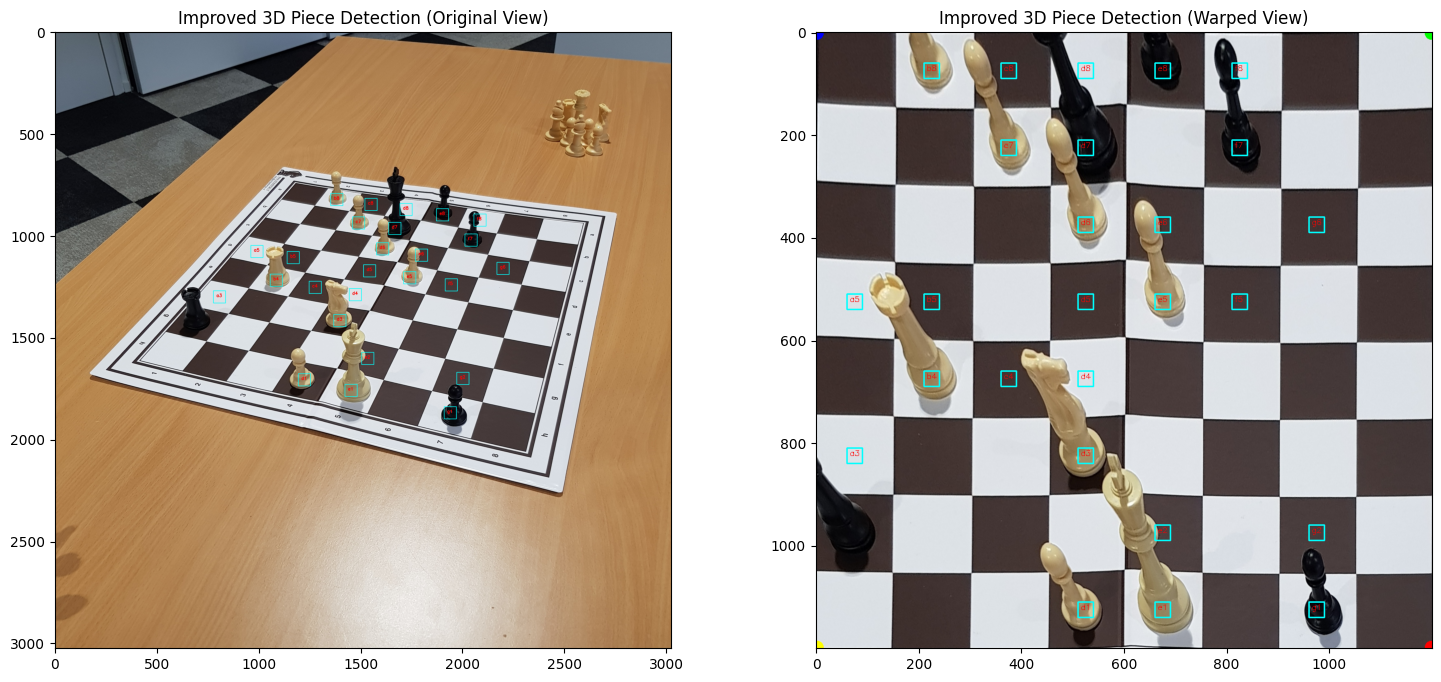

Total pieces detected: 26

Board Matrix (1 for piece, 0 for empty):
[0, 1, 1, 1, 1, 1, 0, 0]
[0, 0, 1, 1, 0, 1, 0, 0]
[0, 0, 0, 1, 1, 0, 1, 0]
[1, 1, 0, 1, 1, 1, 0, 0]
[0, 1, 1, 1, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 1, 0]
[0, 0, 0, 1, 1, 0, 1, 0]

Output for assignment submission:
Total pieces: 26

Piece positions:
['g1', 'd8', 'f8', 'd3', 'd7', 'd1', 'e1', 'd6', 'b8', 'e6', 'c4', 'e5', 'b4', 'e2', 'c7', 'f7', 'e8', 'c8', 'b5', 'd4', 'a5', 'd5', 'g2', 'a3', 'g6', 'f5']


In [89]:
# Improved Chess Piece Detection for 3D Pieces
# This addresses the issue of tall pieces appearing to occupy multiple squares

def detect_pieces_improved_3d(rgb_image, squares_data, warped_image, M, M_inv):
    """
    Detect pieces with special handling for tall pieces in 3D perspective
    
    Args:
        rgb_image: Original RGB image
        squares_data: List of dictionaries containing square information
        warped_image: The top-down warped view of the board
        M: Perspective transformation matrix
        M_inv: Inverse perspective transformation matrix
        
    Returns:
        Dictionary with piece information and visualization
    """
    # Create visualization copies
    visualization = rgb_image.copy()
    warped_viz = warped_image.copy()
    
    # Convert to grayscale
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    warped_gray = cv2.cvtColor(warped_image, cv2.COLOR_RGB2GRAY)
    
    # Calculate warped square size
    square_width = warped_image.shape[1] // 8
    square_height = warped_image.shape[0] // 8
    
    # Initialize counters and storage
    pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # First, analyze the warped image to get base features for each square
    warped_square_features = []
    
    for i in range(8):  # Rank (rows)
        for j in range(8):  # File (columns)
            # Calculate square boundaries in warped image
            x1 = j * square_width
            y1 = i * square_height
            x2 = (j + 1) * square_width
            y2 = (i + 1) * square_height
            
            # Get center point
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            
            # Extract the square area
            square_img = warped_gray[y1:y2, x1:x2]
            
            # Calculate features
            std_dev = np.std(square_img)
            
            # Edge detection
            edges = cv2.Canny(square_img, 50, 150)
            edge_pixels = np.count_nonzero(edges)
            edge_density = edge_pixels / square_img.size if square_img.size > 0 else 0
            
            # Determine if square is dark or light
            is_dark_square = (i + j) % 2 == 1
            
            # Calculate piece score
            piece_score = std_dev + (edge_density * 400)
            
            # Store features
            file_letter = chr(97 + j)  # 'a' to 'h'
            rank_number = 8 - i  # 1 to 8 (top to bottom)
            
            warped_square_features.append({
                "position": f"{file_letter}{rank_number}",
                "file_idx": j,
                "rank_idx": i,
                "warped_center": (center_x, center_y),
                "is_dark_square": is_dark_square,
                "std_dev": std_dev,
                "edge_density": edge_density,
                "piece_score": piece_score
            })
    
    # Sort squares by piece score (higher score = more likely to have a piece)
    sorted_squares = sorted(warped_square_features, key=lambda x: x["piece_score"], reverse=True)
    
    # Analyze the distribution to find a threshold
    scores = [square["piece_score"] for square in warped_square_features]
    
    if len(scores) > 0:
        # Sort scores
        sorted_scores = sorted(scores, reverse=True)
        
        # In a standard chess game, we expect around 32 pieces
        # But this could be mid-game, so adaptively find a threshold
        # Look for a significant gap in the scores
        max_gap = 0
        gap_idx = len(sorted_scores) // 2  # Default to middle
        
        for i in range(5, len(sorted_scores)-5):
            gap = sorted_scores[i] - sorted_scores[i+1]
            if gap > max_gap:
                max_gap = gap
                gap_idx = i
        
        # If a clear gap is found, use it; otherwise use a reasonable estimate
        if max_gap > np.std(sorted_scores) * 0.5:
            detection_threshold = (sorted_scores[gap_idx] + sorted_scores[gap_idx+1]) / 2
        else:
            # Use a percentile-based approach
            detection_threshold = np.percentile(scores, 60)  # Adjust if needed
    else:
        detection_threshold = 25  # Fallback value
    
    print(f"Piece detection threshold: {detection_threshold}")
    
    # Now detect pieces with conflict resolution for tall pieces
    detected_positions = set()  # Track which positions already have pieces
    
    # First pass: Process squares with highest piece scores first
    for square in sorted_squares:
        position = square["position"]
        file_idx = square["file_idx"]
        rank_idx = square["rank_idx"]
        piece_score = square["piece_score"]
        warped_center = square["warped_center"]
        
        # Determine if there's a piece based on score
        has_piece = piece_score > detection_threshold
        
        # Skip if we've already placed a piece here
        if position in detected_positions:
            continue
        
        if has_piece:
            # Mark this position as having a piece
            detected_positions.add(position)
            
            # Transform warped center back to original image
            warped_point = np.array([[[warped_center[0], warped_center[1]]]], dtype=np.float32)
            original_point = cv2.perspectiveTransform(warped_point, M_inv)
            original_center = (int(original_point[0][0][0]), int(original_point[0][0][1]))
            
            # Create bounding box in original image
            roi_size = 30  # Smaller ROI for more precise piece location
            roi_x = max(0, original_center[0] - roi_size)
            roi_y = max(0, original_center[1] - roi_size)
            roi_width = min(roi_size*2, rgb_image.shape[1] - roi_x)
            roi_height = min(roi_size*2, rgb_image.shape[0] - roi_y)
            
            # Create bounding box in warped image
            warped_roi_x = max(0, warped_center[0] - 15)
            warped_roi_y = max(0, warped_center[1] - 15)
            warped_roi_width = 30
            warped_roi_height = 30
            
            # Draw on original visualization
            cv2.rectangle(visualization, (roi_x, roi_y), (roi_x+roi_width, roi_y+roi_height), (0, 255, 255), 2)
            
            # Draw on warped visualization
            cv2.rectangle(warped_viz, (warped_roi_x, warped_roi_y), 
                         (warped_roi_x+warped_roi_width, warped_roi_y+warped_roi_height), 
                         (0, 255, 255), 2)
            
            # Add position label to both visualizations
            cv2.putText(visualization, position, (original_center[0]-15, original_center[1]), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            
            cv2.putText(warped_viz, position, (warped_center[0]-10, warped_center[1]), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            
            # Update the board matrix (1 indicates piece present)
            board_matrix[rank_idx][file_idx] = 1
            
            # Store piece information
            piece_data = {
                "position": position,
                "center": original_center,
                "bbox": (roi_x, roi_y, roi_width, roi_height),
                "piece_score": piece_score
            }
            
            # Add to pieces list
            pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "total_pieces_count": len(pieces),
        "pieces": pieces,
        "board_matrix": board_matrix,
        "warped_visualization": warped_viz
    }
    
    return result, visualization

# Run the improved 3D piece detection
improved_3d_result, improved_3d_viz = detect_pieces_improved_3d(rgb_image, squares_data, warped_image, M, M_inv)

# Display the results
plt.figure(figsize=(18, 8))
plt.subplot(121)
plt.imshow(improved_3d_viz)
plt.title("Improved 3D Piece Detection (Original View)")

plt.subplot(122)
plt.imshow(improved_3d_result["warped_visualization"])
plt.title("Improved 3D Piece Detection (Warped View)")
plt.show()

# Print statistics
print(f"Total pieces detected: {improved_3d_result['total_pieces_count']}")

# Display the board matrix (0 for empty, 1 for occupied)
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in improved_3d_result['board_matrix']:
    print(row)

# Format the output for assignment submission
output_data = {
    "piece_count": improved_3d_result['total_pieces_count'],
    "piece_positions": [p["position"] for p in improved_3d_result["pieces"]],
    "board_matrix": improved_3d_result["board_matrix"]
}

# Print the formatted output
print("\nOutput for assignment submission:")
print(f"Total pieces: {output_data['piece_count']}")
print("\nPiece positions:")
print(output_data['piece_positions'])

# END

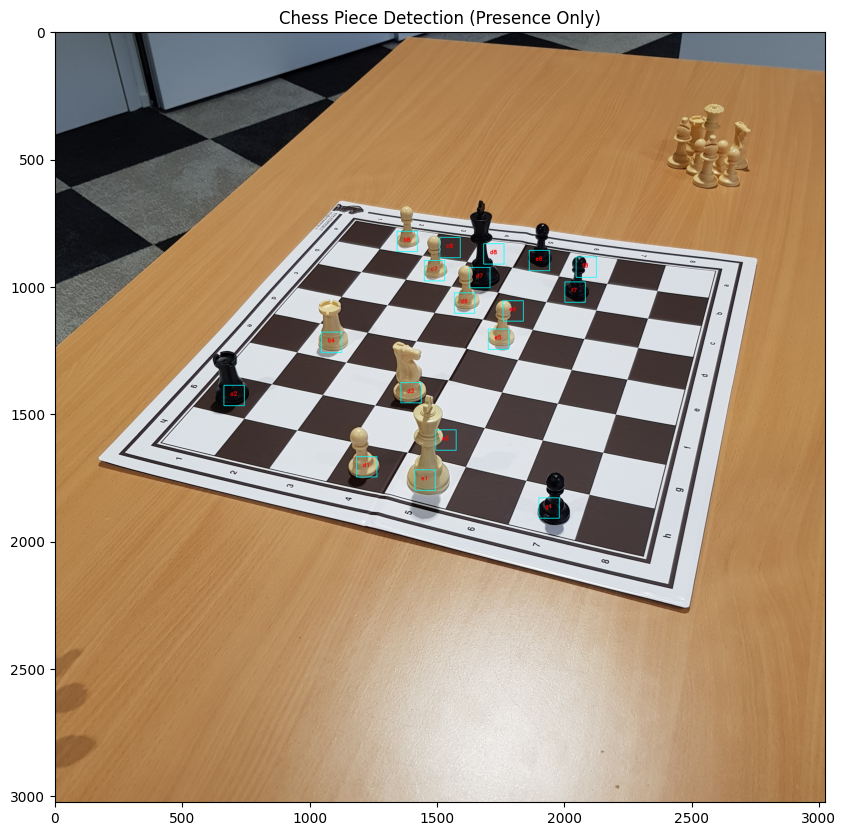

Total pieces detected: 18

Board Matrix (1 for piece, 0 for empty):
[0, 1, 1, 1, 1, 1, 0, 0]
[0, 0, 1, 1, 0, 1, 0, 0]
[0, 0, 0, 1, 1, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 0, 0, 0, 1, 0, 0, 0]
[0, 0, 0, 1, 1, 0, 1, 0]

Output for assignment submission:
Total pieces: 18

Piece positions:
['d1', 'e1', 'g1', 'a2', 'e2', 'd3', 'b4', 'e5', 'd6', 'e6', 'c7', 'd7', 'f7', 'b8', 'c8', 'd8', 'e8', 'f8']


In [88]:
# Simplified Chess Piece Detection - Only Detecting Piece Presence
# No differentiation between white and black pieces

def detect_pieces_presence_only(rgb_image, squares_data):
    """
    Detect only if a piece is present, without distinguishing colors
    
    Args:
        rgb_image: Original RGB image
        squares_data: List of dictionaries containing square information
        
    Returns:
        Dictionary with piece information and visualization
    """
    # Create a visualization copy of the original image
    visualization = rgb_image.copy()
    
    # Convert to grayscale for simpler processing
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    
    # Initialize counters and storage
    pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # Process each square individually
    for square in squares_data:
        # Get the original center of the square
        center = square["original_center"]
        
        # Get square coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')  # 0-7
        rank_idx = 8 - rank  # 0-7 (8 is at the top in chess notation)
        
        # Determine if square is dark or light on the chessboard
        is_dark_square = (file_idx + rank_idx) % 2 == 1
        
        # Define a region around the center to analyze
        roi_size = 40  # Larger ROI to capture more of the piece
        roi_x = max(0, center[0] - roi_size)
        roi_y = max(0, center[1] - roi_size)
        roi_width = min(roi_size*2, rgb_image.shape[1] - roi_x)
        roi_height = min(roi_size*2, rgb_image.shape[0] - roi_y)
        
        # Extract the region of interest
        roi_gray = gray_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        
        if roi_gray.size == 0:
            continue  # Skip if ROI is outside the image
        
        # FEATURE 1: Standard deviation of brightness (pieces create shadows and highlights)
        std_dev = np.std(roi_gray)
        
        # FEATURE 2: Edge density (pieces have more edges)
        edges = cv2.Canny(roi_gray, 50, 150)
        edge_pixels = np.count_nonzero(edges)
        edge_density = edge_pixels / roi_gray.size
        
        # Calculate a simple "piece presence score"
        piece_score = std_dev + (edge_density * 500)
        
        # Threshold for piece detection - adjust as needed
        # Higher on dark squares since they naturally have more contrast
        piece_threshold = 25 if is_dark_square else 20
        
        # Determine if there's a piece
        has_piece = piece_score > piece_threshold
        
        if has_piece:
            # Create bounding box
            bbox = (roi_x, roi_y, roi_width, roi_height)
            
            # Draw on visualization - single color for all pieces
            cv2.rectangle(visualization, (roi_x, roi_y), (roi_x+roi_width, roi_y+roi_height), (0, 255, 255), 2)
            
            # Add position label
            cv2.putText(visualization, f"{file}{rank}", (center[0]-15, center[1]), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            
            # Update the board matrix (1 indicates piece present)
            board_matrix[rank_idx][file_idx] = 1
            
            # Store piece information
            piece_data = {
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox
            }
            
            # Add to pieces list
            pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "total_pieces_count": len(pieces),
        "pieces": pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Run the simplified detection (piece presence only)
presence_result, presence_visualization = detect_pieces_presence_only(rgb_image, squares_data)

# Display the result
plt.figure(figsize=(12, 10))
plt.imshow(presence_visualization)
plt.title("Chess Piece Detection (Presence Only)")
plt.show()

# Print statistics
print(f"Total pieces detected: {presence_result['total_pieces_count']}")

# Display the board matrix (0 for empty, 1 for occupied)
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in presence_result['board_matrix']:
    print(row)

# Format the output for assignment submission
output_data = {
    "piece_count": presence_result['total_pieces_count'],
    "piece_positions": [p["position"] for p in presence_result["pieces"]],
    "board_matrix": presence_result["board_matrix"]
}

# Print the formatted output
print("\nOutput for assignment submission:")
print(f"Total pieces: {output_data['piece_count']}")
print("\nPiece positions:")
print(output_data['piece_positions'])

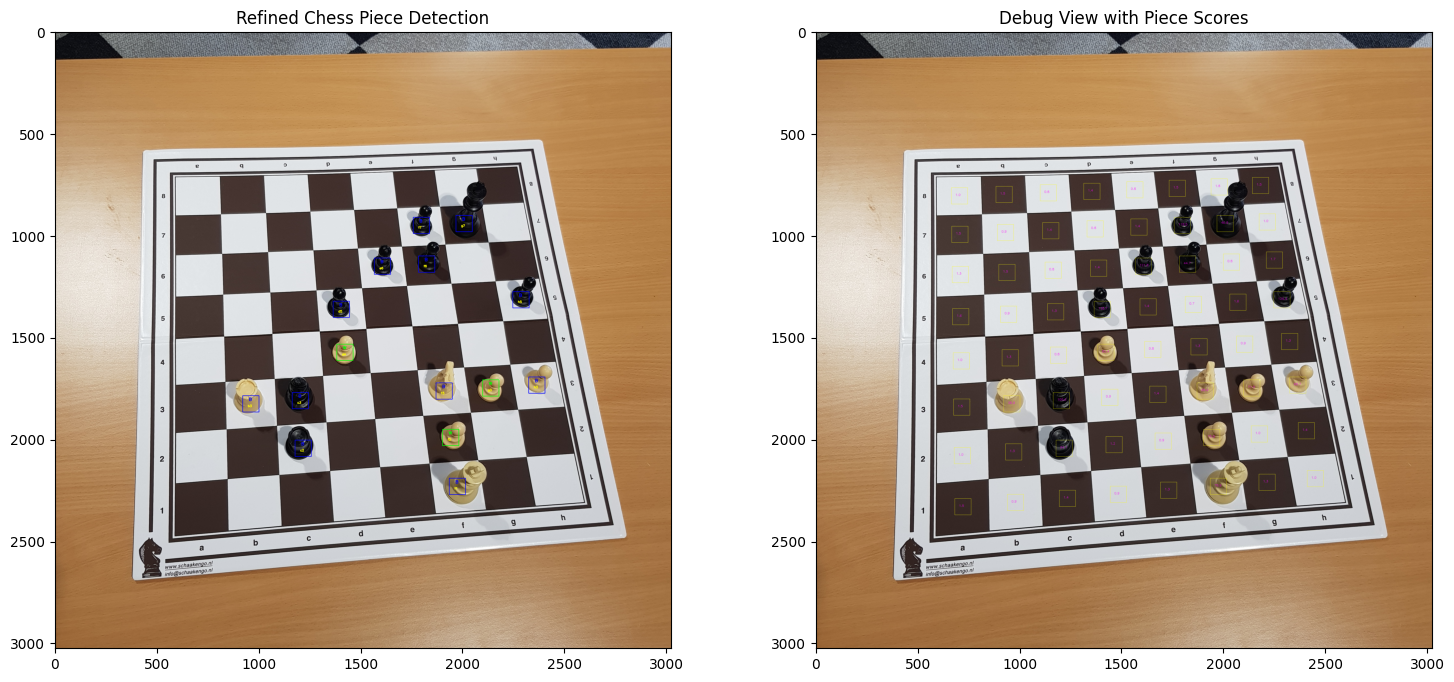

Total pieces detected: 15
White pieces: 3
Black pieces: 12

Board Matrix (1 for piece, 0 for empty):
[0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 1, 1, 0]
[0, 0, 0, 0, 1, 1, 0, 0]
[0, 0, 0, 1, 0, 0, 0, 1]
[0, 0, 0, 1, 0, 0, 0, 0]
[0, 1, 1, 0, 0, 1, 1, 1]
[0, 0, 1, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 1, 0, 0]


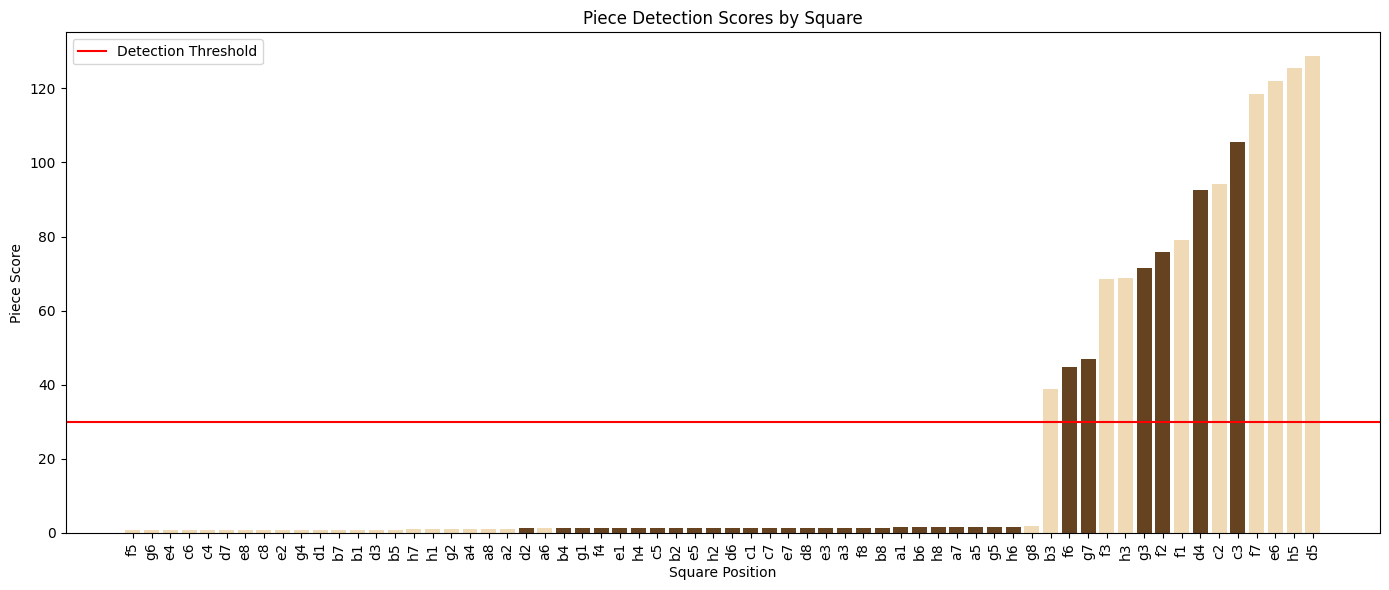

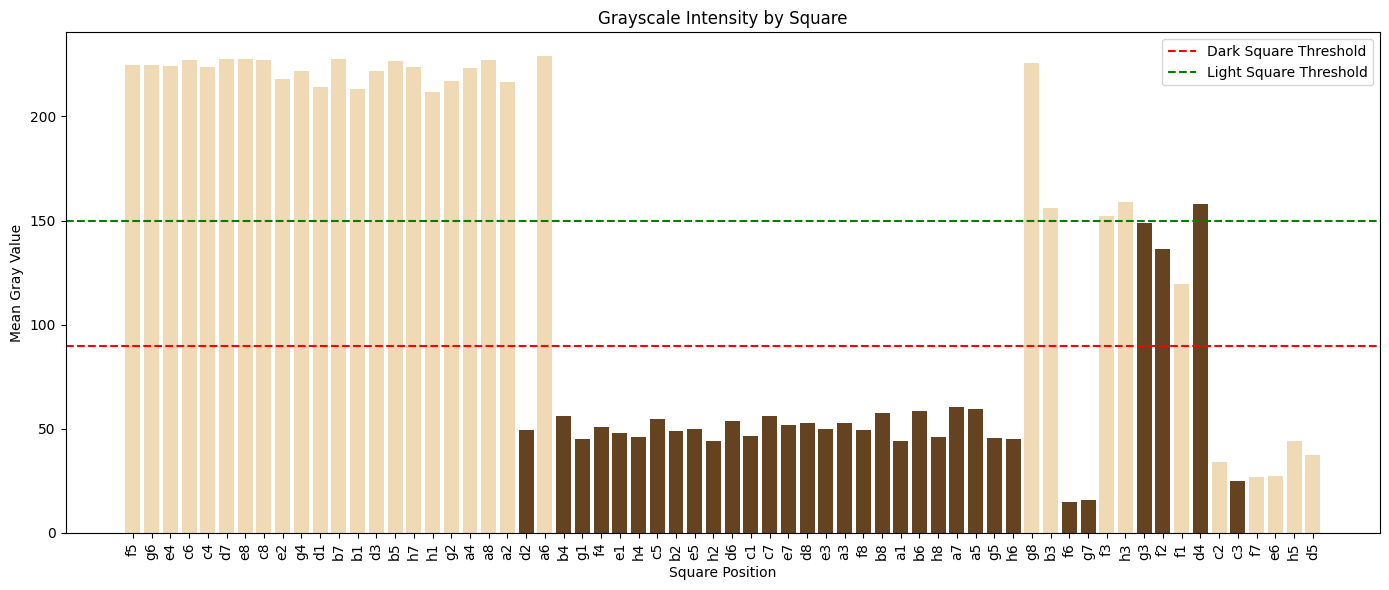

In [43]:
# Refined Chess Piece Detection Algorithm
# With improved thresholds and color analysis

def detect_chess_pieces_refined(rgb_image, squares_data, M_inv):
    """
    Improved detection with better thresholds and debugging
    
    Args:
        rgb_image: Original RGB image
        squares_data: List of dictionaries containing square information
        M_inv: Inverse perspective transformation matrix
        
    Returns:
        Dictionary with piece information and visualization
    """
    # Create a visualization copy of the original image
    visualization = rgb_image.copy()
    debug_visualization = rgb_image.copy()  # For debugging purposes
    
    # Convert to different color spaces for better analysis
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    
    # Initialize counters and storage
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # Store features for all squares to help with calibration
    all_square_features = []
    
    # Process each square individually
    for square in squares_data:
        # Get the original center of the square
        center = square["original_center"]
        
        # Get square coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')  # 0-7
        rank_idx = 8 - rank  # 0-7 (8 is at the top in chess notation)
        
        # Define a region around the center to analyze
        roi_size = 40  # Larger ROI to capture more of the piece
        roi_x = max(0, center[0] - roi_size)
        roi_y = max(0, center[1] - roi_size)
        roi_width = min(roi_size*2, rgb_image.shape[1] - roi_x)
        roi_height = min(roi_size*2, rgb_image.shape[0] - roi_y)
        
        # Extract the region of interest from different color spaces
        roi_rgb = rgb_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        roi_hsv = hsv_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        roi_gray = gray_image[roi_y:roi_y+roi_height, roi_x:roi_x+roi_width]
        
        if roi_rgb.size == 0 or roi_hsv.size == 0 or roi_gray.size == 0:
            continue  # Skip if ROI is outside the image
        
        # Calculate various features
        # HSV features
        mean_hue = np.mean(roi_hsv[:,:,0])
        mean_sat = np.mean(roi_hsv[:,:,1])
        mean_val = np.mean(roi_hsv[:,:,2])
        std_val = np.std(roi_hsv[:,:,2])
        
        # RGB features
        mean_r = np.mean(roi_rgb[:,:,0])
        mean_g = np.mean(roi_rgb[:,:,1])
        mean_b = np.mean(roi_rgb[:,:,2])
        
        # Grayscale features
        mean_gray = np.mean(roi_gray)
        std_gray = np.std(roi_gray)
        
        # Calculate edge features to detect piece presence
        edges = cv2.Canny(roi_gray, 50, 150)
        edge_pixels = np.count_nonzero(edges)
        edge_density = edge_pixels / roi_gray.size
        
        # Calculate a "piece likelihood score" based on multiple features
        piece_score = (
            std_gray * 0.5 +           # Higher standard deviation for pieces (shadows/highlights)
            edge_density * 500 +        # More edges for pieces
            std_val * 0.5              # Higher standard deviation in brightness for pieces
        )
        
        # Determine if square has dark or light background
        is_dark_square = (file_idx + rank_idx) % 2 == 1
        
        # Store all features for analysis
        all_square_features.append({
            "position": f"{file}{rank}",
            "is_dark_square": is_dark_square,
            "mean_gray": mean_gray,
            "std_gray": std_gray,
            "edge_density": edge_density,
            "mean_r": mean_r,
            "mean_g": mean_g,
            "mean_b": mean_b,
            "mean_hue": mean_hue,
            "mean_sat": mean_sat,
            "mean_val": mean_val,
            "piece_score": piece_score
        })
        
        # Draw the ROI rectangle for debugging
        cv2.rectangle(debug_visualization, (roi_x, roi_y), (roi_x+roi_width, roi_y+roi_height), (255, 255, 0), 1)
        
        # Add piece score as text for debugging
        cv2.putText(debug_visualization, f"{piece_score:.1f}", (center[0]-20, center[1]), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 1)
        
        # Determine if there's a piece based on piece score
        # Calibrate this threshold based on your specific image
        has_piece = piece_score > 30  # Adjust as needed
        
        # Determine piece color based on color features
        # This is a critical part that needs calibration
        if has_piece:
            # For white pieces on your board:
            # - Higher brightness (mean_gray)
            # - Lower saturation (they're pearlescent)
            # - Higher red and green components relative to blue
            
            # Adjust thresholds based on square color
            if is_dark_square:
                # On dark squares
                is_white_piece = (mean_gray > 90) and (mean_r > 90) and (mean_g > 90)
            else:
                # On light squares
                is_white_piece = (mean_gray > 150) and (mean_sat < 50)
            
            piece_color = "white" if is_white_piece else "black"
            
            # Create a bounding box around the center
            bbox = (roi_x, roi_y, roi_width, roi_height)
            
            # Draw bounding box
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            cv2.rectangle(visualization, (roi_x, roi_y), (roi_x+roi_width, roi_y+roi_height), color, 2)
            
            # Add label
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, label, (center[0]-10, center[1]-15), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            # Add position label
            cv2.putText(visualization, f"{file}{rank}", (center[0]-15, center[1]+15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix (1 indicates piece present)
            board_matrix[rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "features": {
                    "mean_gray": mean_gray,
                    "std_gray": std_gray,
                    "mean_sat": mean_sat,
                    "mean_val": mean_val
                }
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix,
        "square_features": all_square_features,
        "debug_visualization": debug_visualization
    }
    
    return result, visualization

# Apply the refined piece detection
refined_result, refined_visualization = detect_chess_pieces_refined(rgb_image, squares_data, M_inv)

# Display the results
plt.figure(figsize=(18, 8))
plt.subplot(121)
plt.imshow(refined_visualization)
plt.title("Refined Chess Piece Detection")

plt.subplot(122)
plt.imshow(refined_result["debug_visualization"])
plt.title("Debug View with Piece Scores")
plt.show()

# Print statistics
print(f"Total pieces detected: {refined_result['total_pieces_count']}")
print(f"White pieces: {refined_result['white_pieces_count']}")
print(f"Black pieces: {refined_result['black_pieces_count']}")

# Display the board matrix
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in refined_result['board_matrix']:
    print(row)

# Analyze feature distributions to help with debugging
# Create scatter plots of key features
square_features = refined_result['square_features']

# Sort by piece score
sorted_features = sorted(square_features, key=lambda x: x['piece_score'])

# Extract data for visualization
positions = [f['position'] for f in sorted_features]
scores = [f['piece_score'] for f in sorted_features]
gray_means = [f['mean_gray'] for f in sorted_features]
square_colors = ['#654321' if f['is_dark_square'] else '#f0d9b5' for f in sorted_features]

# Create a visualization of piece scores
plt.figure(figsize=(14, 6))
plt.bar(positions, scores, color=square_colors)
plt.axhline(y=30, color='r', linestyle='-', label='Detection Threshold')
plt.title("Piece Detection Scores by Square")
plt.xlabel("Square Position")
plt.ylabel("Piece Score")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Create a visualization of grayscale means (useful for color determination)
plt.figure(figsize=(14, 6))
plt.bar(positions, gray_means, color=square_colors)
plt.axhline(y=90, color='r', linestyle='--', label='Dark Square Threshold')
plt.axhline(y=150, color='g', linestyle='--', label='Light Square Threshold')
plt.title("Grayscale Intensity by Square")
plt.xlabel("Square Position")
plt.ylabel("Mean Gray Value")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

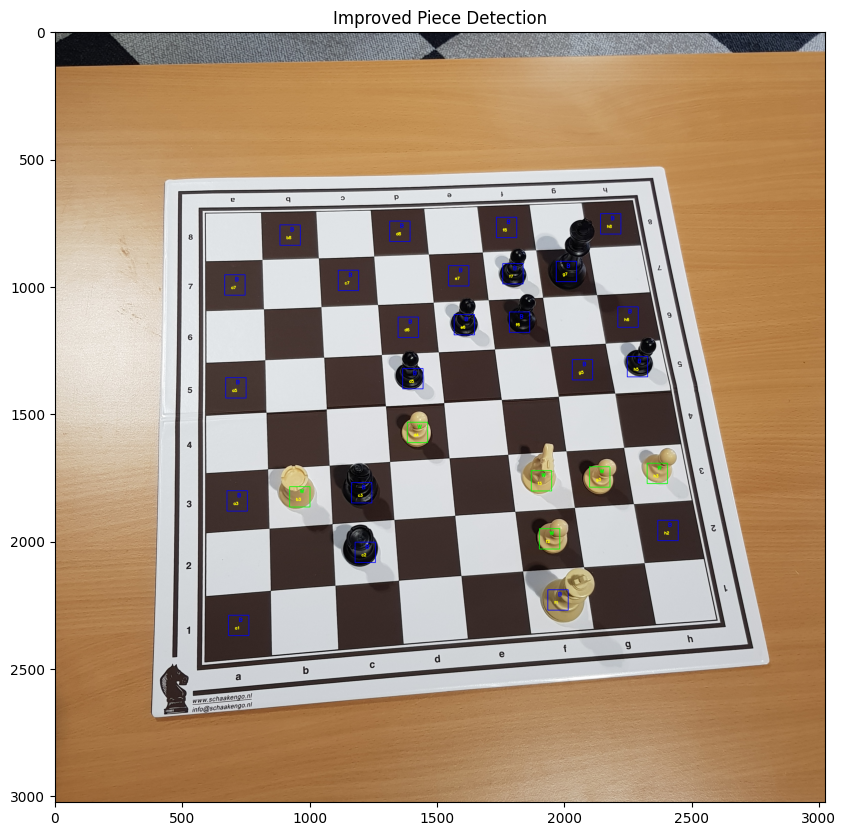

Total pieces detected: 29
White pieces: 6
Black pieces: 23

Board Matrix (1 for piece, 0 for empty):
[0, 1, 0, 1, 0, 1, 0, 1]
[1, 0, 1, 0, 1, 1, 1, 0]
[0, 0, 0, 1, 1, 1, 0, 1]
[1, 0, 0, 1, 0, 0, 1, 1]
[0, 0, 0, 1, 0, 0, 0, 0]
[1, 1, 1, 0, 0, 1, 1, 1]
[0, 0, 1, 0, 0, 1, 0, 1]
[1, 0, 0, 0, 0, 1, 0, 0]


In [41]:
# Improved Chess Piece Detection
# Instead of using color segmentation, let's use a more robust approach
# We'll analyze each square individually to detect pieces

def detect_pieces_in_squares(image, squares_data):
    """
    Detect chess pieces by analyzing each square individually
    
    Args:
        image: Original RGB image
        squares_data: List containing square information
    
    Returns:
        Detection results
    """
    # Convert to grayscale for easier processing
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Create a visualization image
    visualization = image.copy()
    
    # Keep track of pieces
    white_pieces = []
    black_pieces = []
    
    # Create a matrix to represent the board (0 for empty, 1 for occupied)
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # Define a function to transform coordinates from warped space to original space
    def transform_to_original(warped_coords, M_inv):
        coords = np.array([warped_coords], dtype=np.float32).reshape(-1, 1, 2)
        transformed = cv2.perspectiveTransform(coords, M_inv)
        return (int(transformed[0][0][0]), int(transformed[0][0][1]))
    
    # For each square, extract features and determine if a piece is present
    for square_idx, square in enumerate(squares_data):
        # Get the original center of the square
        center = square["original_center"]
        rank = square["rank"]
        file = square["file"]
        
        # Define a region of interest (ROI) around the center
        roi_size = 50  # Adjust as needed
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI
        roi = gray_image[y1:y2, x1:x2]
        
        if roi.size == 0:
            continue  # Skip if ROI is outside image bounds
        
        # Analyze the ROI for features that indicate a piece
        # 1. Variance (pieces typically have higher variance due to shadows and shapes)
        variance = np.var(roi)
        
        # 2. Histogram features
        hist = cv2.calcHist([roi], [0], None, [32], [0, 256])
        hist_norm = hist / hist.sum()
        hist_entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-7))
        
        # 3. Gradients (pieces typically have stronger gradients)
        sobelx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # Set thresholds for piece detection
        has_piece = variance > 1000 and avg_gradient > 15
        
        # Determine piece color based on pixel intensity
        # Calculate the mean intensity of the ROI
        mean_intensity = np.mean(roi)
        
        # Threshold to distinguish between white and black pieces
        piece_color = "white" if mean_intensity > 127 else "black"
        
        # Create a bounding box around the piece
        bbox = (x1, y1, x2 - x1, y2 - y1)
        
        # File index (0-7) and rank index (0-7)
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            cv2.rectangle(visualization, (x1, y1), (x2, y2), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix (1 indicates piece present)
            # Convert from chess notation (a1 is bottom-left) to matrix indices (0,0 is top-left)
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "features": {
                    "variance": variance,
                    "hist_entropy": hist_entropy,
                    "avg_gradient": avg_gradient,
                    "mean_intensity": mean_intensity
                }
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Improve the detection by fine-tuning the parameters
# We need to adjust the thresholds to better match the image

# Let's add an adaptive approach that examines the distribution of features
def adaptive_piece_detection(image, squares_data):
    """
    Adaptively detect chess pieces by analyzing the distribution of features across squares
    """
    # Create a copy of the image
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    visualization = image.copy()
    
    # Extract features for all squares
    all_square_features = []
    
    for square in squares_data:
        center = square["original_center"]
        roi_size = 40  # Slightly smaller ROI
        
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI
        roi = gray_image[y1:y2, x1:x2]
        
        if roi.size == 0:
            # Skip empty ROIs
            all_square_features.append({
                "square": square,
                "variance": 0,
                "gradient": 0,
                "mean_intensity": 0,
                "bbox": (x1, y1, x2-x1, y2-y1)
            })
            continue
        
        # Calculate features
        variance = np.var(roi)
        
        # Gradient features
        sobelx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # Mean intensity
        mean_intensity = np.mean(roi)
        
        # Store features
        all_square_features.append({
            "square": square,
            "variance": variance,
            "gradient": avg_gradient,
            "mean_intensity": mean_intensity,
            "bbox": (x1, y1, x2-x1, y2-y1)
        })
    
    # Calculate feature distributions
    variances = [f["variance"] for f in all_square_features]
    gradients = [f["gradient"] for f in all_square_features]
    
    # Sort features
    sorted_variances = sorted(variances)
    sorted_gradients = sorted(gradients)
    
    # Adaptively find thresholds using a percentile approach
    # Aim to detect approximately half the squares as containing pieces
    
    # Get variance threshold at 50th percentile (median)
    if len(sorted_variances) > 0:
        variance_threshold = sorted_variances[len(sorted_variances) // 2]
    else:
        variance_threshold = 1000  # Fallback
    
    # Get gradient threshold at 50th percentile
    if len(sorted_gradients) > 0:
        gradient_threshold = sorted_gradients[len(sorted_gradients) // 2]
    else:
        gradient_threshold = 15  # Fallback
    
    # Apply thresholds to detect pieces
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    for features in all_square_features:
        square = features["square"]
        variance = features["variance"]
        gradient = features["gradient"]
        mean_intensity = features["mean_intensity"]
        bbox = features["bbox"]
        
        # Determine if this square contains a piece
        has_piece = variance > variance_threshold and gradient > gradient_threshold
        
        # Set color based on intensity
        piece_color = "white" if mean_intensity > 127 else "black"
        
        # Get chess coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        center = square["original_center"]
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            x1, y1, w, h = bbox
            cv2.rectangle(visualization, (x1, y1), (x1+w, y1+h), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "features": {
                    "variance": variance,
                    "gradient": gradient,
                    "mean_intensity": mean_intensity
                }
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Run the improved detection
adaptive_detection_result, adaptive_visualization = adaptive_piece_detection(rgb_image, squares_data)

# Display the improved detection
plt.figure(figsize=(12, 10))
plt.imshow(adaptive_visualization)
plt.title("Improved Piece Detection")
plt.show()

# Print statistics
print(f"Total pieces detected: {adaptive_detection_result['total_pieces_count']}")
print(f"White pieces: {adaptive_detection_result['white_pieces_count']}")
print(f"Black pieces: {adaptive_detection_result['black_pieces_count']}")

# Display the board matrix
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in adaptive_detection_result['board_matrix']:
    print(row)

Piece detection threshold: 2.8532082728808104


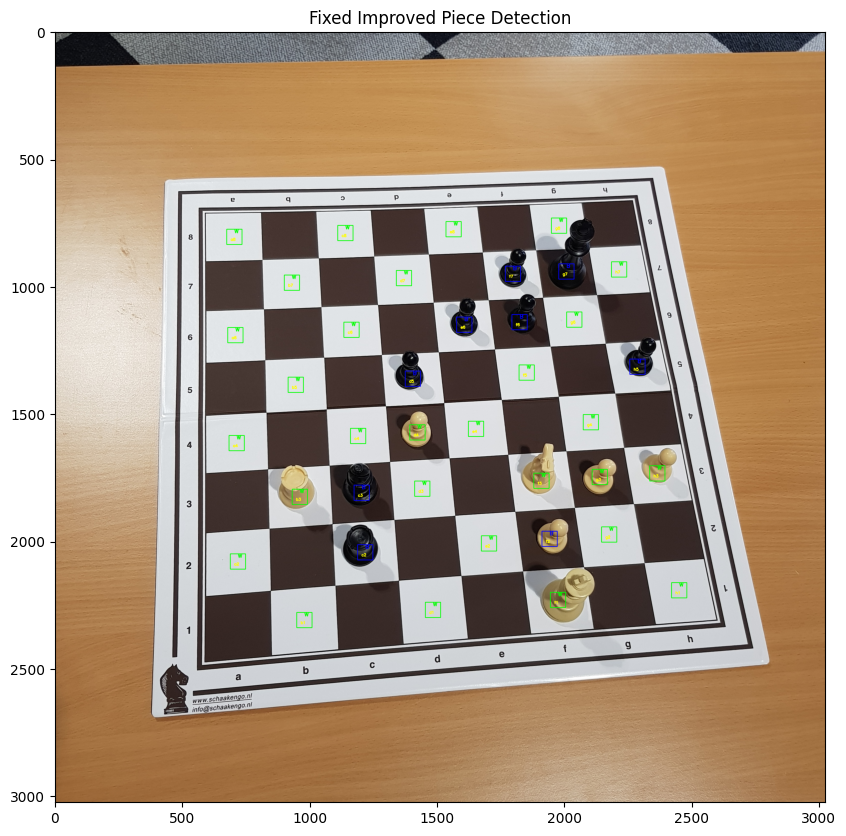

Total pieces detected: 38
White pieces: 29
Black pieces: 9

Board Matrix (1 for piece, 0 for empty):
[1, 0, 1, 0, 1, 0, 1, 0]
[0, 1, 0, 1, 0, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 0]
[0, 1, 0, 1, 0, 1, 0, 1]
[1, 0, 1, 1, 1, 0, 1, 0]
[0, 1, 1, 1, 0, 1, 1, 1]
[1, 0, 1, 0, 1, 1, 1, 0]
[0, 1, 0, 1, 0, 1, 0, 1]


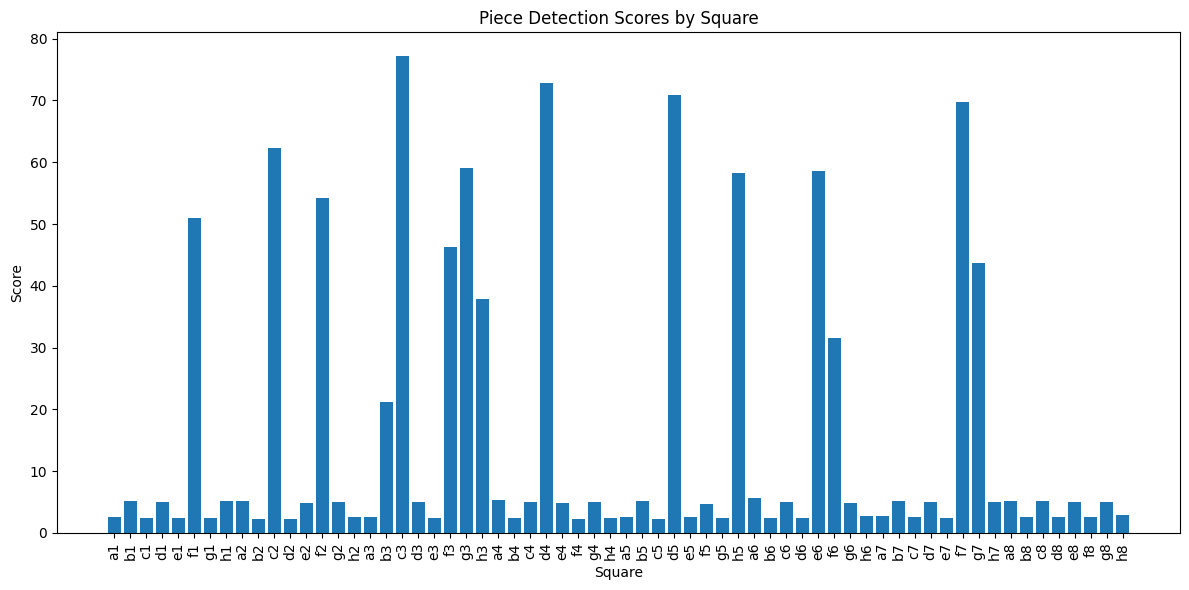

In [42]:
# Fixed improved chess piece detection
# Let's remove the Otsu thresholding that was causing the error
# and implement a simpler but reliable thresholding method

def advanced_piece_detection(image, squares_data):
    """
    Advanced chess piece detection with improved feature extraction
    and refined thresholds, with fixes for the errors
    """
    # Create a copy of the image
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    visualization = image.copy()
    
    # Extract and analyze features for all squares
    all_square_features = []
    
    # For visualization of decision process
    feature_values = []
    
    for square in squares_data:
        center = square["original_center"]
        
        # Use a percentage of the square size instead of fixed size
        # Estimate square size from the data
        roi_size = 30  # Start with a smaller ROI to avoid board border
        
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI from both grayscale and color images
        roi_gray = gray_image[y1:y2, x1:x2]
        roi_color = image[y1:y2, x1:x2]
        
        if roi_gray.size == 0 or roi_color.size == 0:
            # Skip empty ROIs
            all_square_features.append({
                "square": square,
                "score": 0,
                "mean_intensity": 0,
                "bbox": (x1, y1, x2-x1, y2-y1),
                "has_piece": False
            })
            continue
        
        # 1. Calculate basic features
        variance = np.var(roi_gray)
        std_dev = np.std(roi_gray)
        
        # 2. Edge and gradient features
        # Use Canny edge detection
        edges = cv2.Canny(roi_gray, 50, 150)
        edge_pixels = np.count_nonzero(edges)
        edge_density = edge_pixels / roi_gray.size
        
        # Sobel gradients
        sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # 3. Color features (simpler approach without GLCM)
        hsv_roi = cv2.cvtColor(roi_color, cv2.COLOR_RGB2HSV)
        saturation = np.mean(hsv_roi[:,:,1])
        value = np.mean(hsv_roi[:,:,2])
        
        # 4. Calculate mean intensity (for piece color determination)
        mean_intensity = np.mean(roi_gray)
        
        # 5. Shape features - using contours
        _, thresh = cv2.threshold(roi_gray, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Number of contours and largest contour area
        num_contours = len(contours)
        max_contour_area = 0
        if contours:
            max_contour_area = max(cv2.contourArea(cnt) for cnt in contours)
        
        # Combine features into a "piece likelihood score"
        # This is a weighted combination of features that indicate a piece is present
        piece_score = (
            0.3 * std_dev +                # Higher for pieces
            0.3 * edge_density * 1000 +    # Higher for pieces 
            0.3 * avg_gradient +           # Higher for pieces
            0.1 * max_contour_area / 100   # Higher for pieces (distinct shapes)
        )
        
        # Store features for analysis
        feature_values.append({
            "position": f"{square['file']}{square['rank']}",
            "std_dev": std_dev,
            "edge_density": edge_density,
            "avg_gradient": avg_gradient,
            "max_contour_area": max_contour_area,
            "piece_score": piece_score
        })
        
        # Store all features
        all_square_features.append({
            "square": square,
            "std_dev": std_dev,
            "edge_density": edge_density,
            "avg_gradient": avg_gradient,
            "score": piece_score,
            "mean_intensity": mean_intensity,
            "bbox": (x1, y1, x2-x1, y2-y1)
        })
    
    # Analyze the distribution of piece scores to determine threshold
    scores = [f["score"] for f in all_square_features]
    sorted_scores = sorted(scores)
    
    # We expect roughly 32 pieces on a chess board at the start of a game
    # But since this may be a game in progress, let's find a natural split point
    
    # Simple percentile-based approach instead of Otsu
    detection_threshold = 0
    
    if len(sorted_scores) > 0:
        # Try to find a natural gap in the middle of the distribution
        if len(sorted_scores) > 10:
            # Look for a significant gap in the middle part of distribution
            middle_start = len(sorted_scores) // 3
            middle_end = 2 * len(sorted_scores) // 3
            
            max_gap = 0
            gap_threshold = sorted_scores[len(sorted_scores) // 2]  # Start with median
            
            for i in range(middle_start, middle_end):
                gap = sorted_scores[i+1] - sorted_scores[i]
                if gap > max_gap:
                    max_gap = gap
                    gap_threshold = sorted_scores[i] + gap/2
            
            # Only use gap if it's significant
            if max_gap > (sorted_scores[-1] - sorted_scores[0]) / 20:
                detection_threshold = gap_threshold
            else:
                # Otherwise use 40th percentile - this assumes about 60% of squares have pieces
                idx = int(len(sorted_scores) * 0.4)
                detection_threshold = sorted_scores[idx]
        else:
            # For small number of squares, use median
            detection_threshold = sorted_scores[len(sorted_scores) // 2]
    
    # Print the threshold for debugging
    print(f"Piece detection threshold: {detection_threshold}")
    
    # Apply threshold to detect pieces
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    for features in all_square_features:
        square = features["square"]
        score = features["score"]
        mean_intensity = features["mean_intensity"]
        bbox = features["bbox"]
        
        # Get chess coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        center = square["original_center"]
        
        # Determine if this square contains a piece
        has_piece = score > detection_threshold
        features["has_piece"] = has_piece
        
        # Set color based on intensity and board position
        # Chess board alternates colors, so we can use this to improve color detection
        is_dark_square = (file_idx + rank_idx) % 2 == 1
        
        # Adjust intensity threshold based on square color
        intensity_threshold = 100 if is_dark_square else 130
        
        piece_color = "white" if mean_intensity > intensity_threshold else "black"
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            x1, y1, w, h = bbox
            cv2.rectangle(visualization, (x1, y1), (x1+w, y1+h), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "score": score
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix,
        "feature_values": feature_values
    }
    
    return result, visualization

# Apply the fixed detection
advanced_detection_result, advanced_visualization = advanced_piece_detection(rgb_image, squares_data)

# Display the improved detection
plt.figure(figsize=(12, 10))
plt.imshow(advanced_visualization)
plt.title("Fixed Improved Piece Detection")
plt.show()

# Print statistics
print(f"Total pieces detected: {advanced_detection_result['total_pieces_count']}")
print(f"White pieces: {advanced_detection_result['white_pieces_count']}")
print(f"Black pieces: {advanced_detection_result['black_pieces_count']}")

# Display the board matrix
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in advanced_detection_result['board_matrix']:
    print(row)

# Visualize feature distributions to help with debugging
# Plot the distribution of piece scores
feature_values = advanced_detection_result['feature_values']
scores = [f["piece_score"] for f in feature_values]
positions = [f["position"] for f in feature_values]

plt.figure(figsize=(12, 6))
plt.bar(positions, scores)
plt.title("Piece Detection Scores by Square")
plt.xlabel("Square")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# PESSOAL, AQUI AINDA NAO ESTA A DETECTAR PERFEITO, MAS ESTA ENCAMINHANDO... SO QUE PARA OUTRAS IMAGENS ESTA FODIDO, ENTAO QUEM FOR MEXER NESTE CODIGO TENTE COM O CLAUDIN FAZER FICAR MELHOR A GENERALIZAR PLSS